---

MD004 - Algoritmos de Clustering

Gerard Pascual Fontanilles

18 - 01 - 2026

# Entrega 1 - Clustering

**Enunciado:** 

Una empresa de helados llamada ``La Vía Láctea`` quiere hacer una campaña de marketing para augmentar la cantidad de clientes. Para hacer esto ha contactado a un equipo de investigación de la prestigiosa universidad de Harvard. Pero no estaban disponibles... <br> Así que decidieron ponerse en contacto con LaSalle para pedir el estudio de mercado a los estudiantes del MUDS.

**Se os pide:** utiliza el dataset ``customer_data.csv`` para encontrar posibles agrupaciones de clientes y así saber cómo enfocar la campaña. Para hacer esto es necesario que se realicen los siguientes apartados:

1. EDA (2.5 p) <br>
    1.1 Variables numéricas (1.25 p) <br>
    1.2 Variables categóricas (1.25 p) <br>
2. Procesado inicial de los datos (1.5 p) <br>
    2.1 Correlaciones (0.75 p) <br>
    2.2 PCA (0.75 p) <br>
3. Clustering (5 p) <br>
    3.1 Agrupación jerárquica (1 p) <br>
    3.2 K-means (1 p) <br>
    3.3 DBSCAN (1 p) <br>
    3.4 Optics  (Opcional +0,5 p. extras) ->  El solamente se aplica si se tiene una nota superior a 5. <br>
4. Justificación decisiones (2 p) <br>
5. Conclusión (1 p) <br>

El equipo de marketing de ``La Vía Láctea´´ pide que como resultado se entregue un estudio (en formato Jupyter notebook) que <u>explique detalladamente los hallazgos encontrados durante el estudio y que plante una propuesta de estrategia para abordar la campaña.<u>

<br><br>


---

## 0. Imports y carga de datos

In [1]:
# --- LIBRERÍAS BASE ---
import pandas as pd
import numpy as np
import math

# --- VISUALIZACIÓN ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# --- ESTADÍSTICA Y PROCESADO ---
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder

# --- REDUCCIÓN DE DIMENSIONALIDAD (PCA) ---
from sklearn.decomposition import PCA

# --- CLUSTERING ---
from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN,
    OPTICS
)
import scipy.cluster.hierarchy as sch

# --- MÉTRICAS Y VECINOS ---
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

In [2]:
df = pd.read_csv('customer_data.csv', delimiter='\t')

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
print(df.isnull().sum())
print(f"Cantidad de nulos encontrados: {df['Income'].isnull().sum()}")

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64
Cantidad de nulos encontrados: 24


#### Observaciones iniciales sobre los datos

Después de cargar el dataset y ejecutar `df.info()`, observamos los siguientes puntos a corregir en el EDA:

1.  **Valores Nulos:** Todas las columnas parecen estar completas excepto `Income`, que tiene solo 2216 valores no nulos y 24 nulos. Tendremos que imputarlos.
2.  **Tipos de datos incorrectos:**
    * `Dt_Customer` (Object): Se está leyendo una fecha como texto. Debemos convertirla a formato *datetime* para poder operar con ella.
    * Variables Booleanas (int64): Variables como `AcceptedCmp` o `Response` aparecen como números, pero lógicamente son categorías binarias (Sí/No). Las trataremos como variables categóricas en el análisis.
3.  **Ingeniería de variables:**
    * `Year_Birth`: Es más útil convertirla a `Age` para facilitar la interpretación en los gráficos.
    * `Dt_Customer`: Es más útil convertirla a `Antiguedad` por la misma razón que la anterior.

A parte eliminamos las columnas `Z_CostContact` y `Z_Revenue` porque no nos interesan ni aportan nada.

In [6]:
df = df.drop(columns=['Z_CostContact', 'Z_Revenue'])

---

## 1. EDA ``(2.5p)``

En este apartado se tienen que estudiar los datos mediante gráficas (scatterplot, barplot, violinplot, pairplot, etc.) y tests (shapiro-wilk, anova, etc.). Se tiene que comentar lo que se está analizando, descubriendo y que decisiones se van a tomar en consecuencia.

El estudio estadístico tiene dos partes:
1) Estudio de variables numéricas ``(1.25p)``
2) Estudio de variables categóricas ``(1.25p)``

### Limpieza, Ingeniería de Variables y Preparación

Antes de iniciar el análisis exploratorio, realizamos una transformación integral del dataset para corregir formatos y generar nuevas métricas de negocio:

1. **Imputación de nulos:** Rellenamos los valores faltantes en `Income` con la **mediana** para evitar que los valores extremos (outliers) distorsionen el promedio.
2. **Formato de Fecha:** Convertimos la columna `Dt_Customer` a tipo `datetime` para poder operar con ella.
3. **Ingeniería de Variables (Tiempo):**
    * Creamos la variable `Age` (Edad) a partir de `Year_Birth`.
    * Creamos la variable `Antiguedad` (días como cliente) tomando como referencia el 1 de Enero de 2015.
4. **Ingeniería de Variables (Negocio):**
    * **`Total_Spend` (Gasto Total):** Sumamos las 6 categorías de productos (Vino, Carne, Fruta, Pescado, Dulces, Oro) para tener una visión unificada del valor monetario del cliente.
    * **`Children_Total` (Hijos en casa):** Unificamos `Kidhome` y `Teenhome` para analizar el impacto total de la carga familiar.
    * **`Total_Accepted_Cmp` (Engagement):** Sumamos las 5 campañas anteriores más la última respuesta (`Response`). Esto genera un score de fidelidad (de 0 a 6) que mide qué tan reactivo es el cliente a nuestras acciones de marketing.
5. **Ajuste de Variables Categóricas:** Convertimos las variables binarias y de respuesta (0 y 1) a tipo categórico para facilitar la visualización en el EDA.

In [7]:
df['Income'] = df['Income'].fillna(df['Income'].median())

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

df['Age'] = 2015 - df['Year_Birth']
fecha_referencia = pd.to_datetime("2015-01-01")
df['Antiguedad'] = (fecha_referencia - df['Dt_Customer']).dt.days

df['Total_Spend'] = (df['MntWines'] + df['MntFruits'] +
                     df['MntMeatProducts'] + df['MntFishProducts'] +
                     df['MntSweetProducts'] + df['MntGoldProds'])

df['Children_Total'] = df['Kidhome'] + df['Teenhome']

df['Total_Accepted_Cmp'] = (df['AcceptedCmp1'].astype(int) +
                            df['AcceptedCmp2'].astype(int) +
                            df['AcceptedCmp3'].astype(int) +
                            df['AcceptedCmp4'].astype(int) +
                            df['AcceptedCmp5'].astype(int) +
                            df['Response'].astype(int))

cols_binarias = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                 'AcceptedCmp4', 'AcceptedCmp5', 'Response', 'Complain']

for col in cols_binarias:
    df[col] = df[col].astype('category')

In [8]:
print("Estructura final del dataset (con nuevas variables):")
df.info()

print("\nVista previa de las nuevas métricas:")
display(df[['ID', 'Dt_Customer', 'Year_Birth', 'Age', 'Antiguedad', 'Total_Spend', 'Kidhome', 'Teenhome', 'Children_Total', 'Total_Accepted_Cmp', 'Complain']].head())

Estructura final del dataset (con nuevas variables):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2240 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   

,ID,Dt_Customer,Year_Birth,Age,Antiguedad,Total_Spend,Kidhome,Teenhome,Children_Total,Total_Accepted_Cmp,Complain
0,5524,2012-09-04,1957,58,849,1617,0,0,0,1,0
1,2174,2014-03-08,1954,61,299,27,1,1,2,0,0
2,4141,2013-08-21,1965,50,498,776,0,0,0,0,0
3,6182,2014-02-10,1984,31,325,53,1,0,1,0,0
4,5324,2014-01-19,1981,34,347,422,1,0,1,0,0


#### Preparamos las listas de variables por grupos
Separamos por numéricas y categóricas, y solo incluimos las que queremos analizar en el EDA.

In [9]:
# Grupo A: Perfil Cliente
vars_num_perfil = ['Age', 'Income', 'Children_Total', 'Recency', 'Antiguedad']
vars_cat_perfil = ['Education', 'Marital_Status', 'Kidhome', 'Teenhome', 'Complain']

# Grupo B: Productos
vars_num_productos = ['Total_Spend', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
                  'MntSweetProducts', 'MntGoldProds']

# Grupo C: Promociones
vars_num_promo = ['Total_Accepted_Cmp', 'NumDealsPurchases']
vars_cat_promo = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']

# Grupo D: Canales
vars_num_canales = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']

### Estudio Variables Numéricas

In [10]:
print("Grupo A: PERFIL DEL CLIENTE")
display(df[vars_num_perfil].describe().T.round(2))
print("\n--> Verificación: Desglose por tipo de hijo (Kid & Teen)")
display(df[['Kidhome', 'Teenhome']].describe().T.round(2))

print("\nGrupo B: PRODUCTOS")
display(df[vars_num_productos].describe().T.round(2))

print("\nGrupo C: PROMOCIONES")
display(df[vars_num_promo].describe().T.round(2))

print("\nGrupo D: CANALES")
display(df[vars_num_canales].describe().T.round(2))

Grupo A: PERFIL DEL CLIENTE


,count,mean,std,min,25%,50%,75%,max
Age,2240.0,46.19,11.98,19.0,38.00,45.0,56.00,122.0
Income,2240.0,52237.98,25037.96,1730.0,35538.75,51381.5,68289.75,666666.0
Children_Total,2240.0,0.95,0.75,0.0,0.00,1.0,1.00,3.0
Recency,2240.0,49.11,28.96,0.0,24.00,49.0,74.00,99.0
Antiguedad,2240.0,539.58,202.12,186.0,366.75,541.5,715.00,885.0



--> Verificación: Desglose por tipo de hijo (Kid & Teen)


,count,mean,std,min,25%,50%,75%,max
Kidhome,2240.0,0.44,0.54,0.0,0.0,0.0,1.0,2.0
Teenhome,2240.0,0.51,0.54,0.0,0.0,0.0,1.0,2.0



Grupo B: PRODUCTOS


,count,mean,std,min,25%,50%,75%,max
Total_Spend,2240.0,605.80,602.25,5.0,68.75,396.0,1045.50,2525.0
MntWines,2240.0,303.94,336.60,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.30,39.77,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.95,225.72,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.53,54.63,0.0,3.00,12.0,50.00,259.0
MntSweetProducts,2240.0,27.06,41.28,0.0,1.00,8.0,33.00,263.0
MntGoldProds,2240.0,44.02,52.17,0.0,9.00,24.0,56.00,362.0



Grupo C: PROMOCIONES


,count,mean,std,min,25%,50%,75%,max
Total_Accepted_Cmp,2240.0,0.45,0.89,0.0,0.0,0.0,1.0,5.0
NumDealsPurchases,2240.0,2.33,1.93,0.0,1.0,2.0,3.0,15.0



Grupo D: CANALES


,count,mean,std,min,25%,50%,75%,max
NumWebPurchases,2240.0,4.08,2.78,0.0,2.0,4.0,6.0,27.0
NumCatalogPurchases,2240.0,2.66,2.92,0.0,0.0,2.0,4.0,28.0
NumStorePurchases,2240.0,5.79,3.25,0.0,3.0,5.0,8.0,13.0
NumWebVisitsMonth,2240.0,5.32,2.43,0.0,3.0,6.0,7.0,20.0


#### **Análisis del Grupo A: PERFIL (Detección de Errores y Estructura)**
Este primer vistazo confirma la necesidad urgente de limpieza y nos da una foto de la demografía base:
* **Confirmación de Outliers (Errores):**
    * **Age:** El máximo es **122 años**. Es un error biológico/dato sucio (nacido ~1893) que debemos eliminar.
    * **Income:** El máximo es **666.666**, mientras que el 75% de la muestra está por debajo de 69k. Este valor extremo distorsionará cualquier cálculo de promedios.
* **Estructura Familiar (`Children_Total`):**
    * La nueva variable funciona perfectamente. El rango es lógico (0 a 3 hijos).
    * La media es **0.95**, lo que indica que el cliente promedio tiene 1 hijo. Cerca del 50% de la base de datos tiene hijos (Mediana = 1).
* **Recency:** Media y Mediana idénticas (~49). Distribución perfectamente uniforme: la captación y retención es constante en el tiempo.

#### **Análisis del Grupo B: PRODUCTOS (Comportamiento de Gasto)**
Las nuevas métricas revelan la verdadera naturaleza transaccional del cliente:
* **`Total_Spend` (La variable Reina):**
    * Revela una **fuerte asimetría positiva**. La Media (**605**) es muy superior a la Mediana (**396**).
    * *Interpretación:* La mayoría de clientes son de "valor bajo/medio", pero el promedio está inflado por unos pocos clientes VIP (Max 2.525) que sostienen la facturación.
* **Jerarquía de Productos:**
    * **Líderes:** Vino (Media 304) y Carne (Media 167) dominan la cesta de la compra.
    * **Nichos:** Fruta, Pescado, Dulces y Oro tienen medianas ridículas (8, 12, 8...). El 50% de los clientes apenas gasta en estas categorías, lo que sugiere que son productos de venta cruzada.

#### **Análisis del Grupo C: PROMOCIONES (Engagement)**
Aquí vemos la efectividad real del Marketing:
* **`Total_Accepted_Cmp` (Fidelidad):**
    * **Dato Crítico:** La Mediana es **0**. Más del 50% de los clientes **nunca** ha aceptado una campaña.
    * Sin embargo, el Máximo es **5**. Esto confirma la existencia de un clúster de "Brand Lovers" o "Super Fans" que reaccionan a todo. El objetivo del clustering será encontrarlos.
* **`NumDealsPurchases`:** Con una media de 2.33 y un máximo de 15, vemos que hay un segmento sensible al precio (cazadores de ofertas) que se comporta distinto al que acepta campañas de marketing.

#### **Análisis del Grupo D: CANALES (Puntos de Contacto)**
¿Dónde interactúa el cliente?
* **Tienda Física (`NumStorePurchases`):** Es el canal rey indiscutible (Media 5.79 y Mediana 5). Es el comportamiento más generalizado y estable (menor desviación estándar relativa).
* **Web vs. Tráfico:**
    * Hay más **Visitas Web** (5.32) que **Compras Web** (4.08).
    * Esto indica un comportamiento habitual de "ROPO" (*Research Online, Purchase Offline*) o "Window Shopping". La web sirve de escaparate.
* **Catálogo:** Es un canal residual para la mayoría (Mediana 2), pero vital para un nicho específico de usuarios intensivos (Máximo 28 compras).

Antes de passar a los gráficos, vemos mas a profundo esos outliers para decidir que hacemos:

In [11]:
print("Edades > 80 años")
edades_altas = df[df['Age'] > 80]['Age'].value_counts().sort_index()
print(edades_altas)

print("\nIngresos > 100.000")
ingresos_altos = df[df['Income'] > 100000]['Income'].sort_values(ascending=False).head(10)
print(f"Total de casos > 100k: {len(df[df['Income'] > 100000])}")

print("Top 10 ingresos más altos:")
print(ingresos_altos)

Edades > 80 años
Age
115    1
116    1
122    1
Name: count, dtype: int64

Ingresos > 100.000
Total de casos > 100k: 13
Top 10 ingresos más altos:
2233    666666.0
617     162397.0
687     160803.0
1300    157733.0
164     157243.0
1653    157146.0
2132    156924.0
655     153924.0
1898    113734.0
646     105471.0
Name: Income, dtype: float64


Procedemos a crear un dataset limpio, `df_clean` eliminando:
* `Edad`: Ponemos que máximo los clientes puedan tener 80 años.
* `Income`: Eliminamos ingresos superiores a los 200K.

In [12]:
indices_originales = df.index
df_clean = df[(df['Age'] < 80) & (df['Income'] < 200000)].copy()

print(f"Filas originales: {len(df)}")
print(f"Filas tras limpiar: {len(df_clean)}")

indices_eliminados = df.index.difference(df_clean.index)
df_eliminados = df.loc[indices_eliminados]

print(f"Hemos eliminado {len(df_eliminados)} clientes atípicos.")

print("\nFilas eliminadas:")
display(df_eliminados[['ID', 'Age', 'Income']])

Filas originales: 2240
Filas tras limpiar: 2236
Hemos eliminado 4 clientes atípicos.

Filas eliminadas:


,ID,Age,Income
192,7829,115,36640.0
239,11004,122,60182.0
339,1150,116,83532.0
2233,9432,38,666666.0


### Análisis Visual y Estadístico Completo (Histogramas, Boxplots y Q-Q Plots)

Con el dataset `df_clean` ya depurado, procedemos a realizar el estudio univariante definitivo. Para ello, hemos diseñado una función que genera un panel con tres perspectivas visuales y una tabla de métricas estadísticas robustas para cada variable.

**1. Panel Visual:**
* **Histograma:** Nos permite observar la forma de la distribución (campana, uniforme, sesgada...) y ubicar la tendencia central mediante una línea roja discontinua (Media).
* **Boxplot (Diagrama de Caja):** Fundamental para visualizar la dispersión y confirmar visualmente los *outliers* restantes.
* **Q-Q Plot (Gráfico Cuantil-Cuantil):** Es la prueba visual definitiva de normalidad. Compara la distribución de nuestros datos (puntos) contra una distribución normal teórica (línea roja). Si los puntos se ajustan a la recta, podemos asumir normalidad.

**2. Validación Estadística:**
* **Test de Shapiro-Wilk:** Test matemático de normalidad (relevante para selección de modelos, aunque sensible al tamaño de la muestra, por lo tanto no lo tendremos en cuenta.).
* **Métricas de Forma (Skewness y Curtosis):**
    * *Asimetría (Skewness):* Cuantifica el sesgo hacia la izquierda o derecha.
    * *Curtosis:* Indica si la distribución es muy "picuda" o tiene colas pesadas (frecuencia de valores extremos).
    * **Desviación Estándar (Std):** Para cuantificar cuánto varían los datos respecto al promedio.

In [13]:
def analizar_grupo(nombre_grupo, lista_vars, df):
    """
    Función para generar Histogramas, Boxplots, Q-Q Plots y tabla estadística
    para un grupo de variables dado.
    """

    vars_por_fila = 2
    n_cols = 6
    n_rows = math.ceil(len(lista_vars) / vars_por_fila)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 3.5 * n_rows))
    fig.suptitle(f"Análisis: {nombre_grupo}", fontsize=18, fontweight='bold', y=1.02)

    axes_flat = axes.flatten() if n_rows > 1 else axes
    stats_resultados = []

    for i, col in enumerate(lista_vars):
        pos_base = i * 3

        ax_hist = axes_flat[pos_base]
        sns.histplot(data=df, x=col, ax=ax_hist, kde=True,
                     color='#3498db', edgecolor="black", linewidth=1)
        media = df[col].mean()
        ax_hist.axvline(media, color='red', linestyle='--', linewidth=2, label='Media')
        ax_hist.set_title(f"Hist: {col}", fontsize=10, fontweight='bold')
        ax_hist.set_xlabel("")
        ax_hist.tick_params(labelsize=8)
        ax_hist.legend(fontsize='x-small')

        ax_box = axes_flat[pos_base + 1]
        sns.boxplot(data=df, x=col, ax=ax_box, color='#e74c3c', width=0.5)
        ax_box.set_title("Boxplot", fontsize=10, color='gray')
        ax_box.set_xlabel("")
        ax_box.tick_params(labelsize=8)

        ax_qq = axes_flat[pos_base + 2]
        (osm, osr), (slope, intercept, r) = stats.probplot(df[col], dist="norm", plot=ax_qq)
        ax_qq.get_lines()[0].set_markerfacecolor('#2ecc71')
        ax_qq.get_lines()[0].set_markeredgecolor('#27ae60')
        ax_qq.get_lines()[0].set_markersize(3)
        ax_qq.get_lines()[1].set_color('#c0392b')
        ax_qq.set_title(f"Q-Q Plot (R²={r**2:.2f})", fontsize=10)
        ax_qq.set_xlabel("Teórico", fontsize=8)
        ax_qq.set_ylabel("Real", fontsize=8)
        ax_qq.tick_params(labelsize=8)

        stat, p_value = stats.shapiro(df[col])
        skew = df[col].skew()
        kurt = df[col].kurt()
        mediana = df[col].median()
        std_dev = df[col].std()

        stats_resultados.append({
            "Variable": col,
            "Media": round(media, 2),
            "Mediana": round(mediana, 2),
            "Std": round(std_dev, 2),
            "Skew": round(skew, 2),
            "Kurt": round(kurt, 2),
            "Shapiro p": f"{p_value:.1e}",
        })

    total_slots = n_rows * n_cols
    vars_dibujadas = len(lista_vars) * 3
    for j in range(vars_dibujadas, total_slots):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.show()

    print(f"Resumen Estadístico - {nombre_grupo}")
    df_stats = pd.DataFrame(stats_resultados)
    display(df_stats)

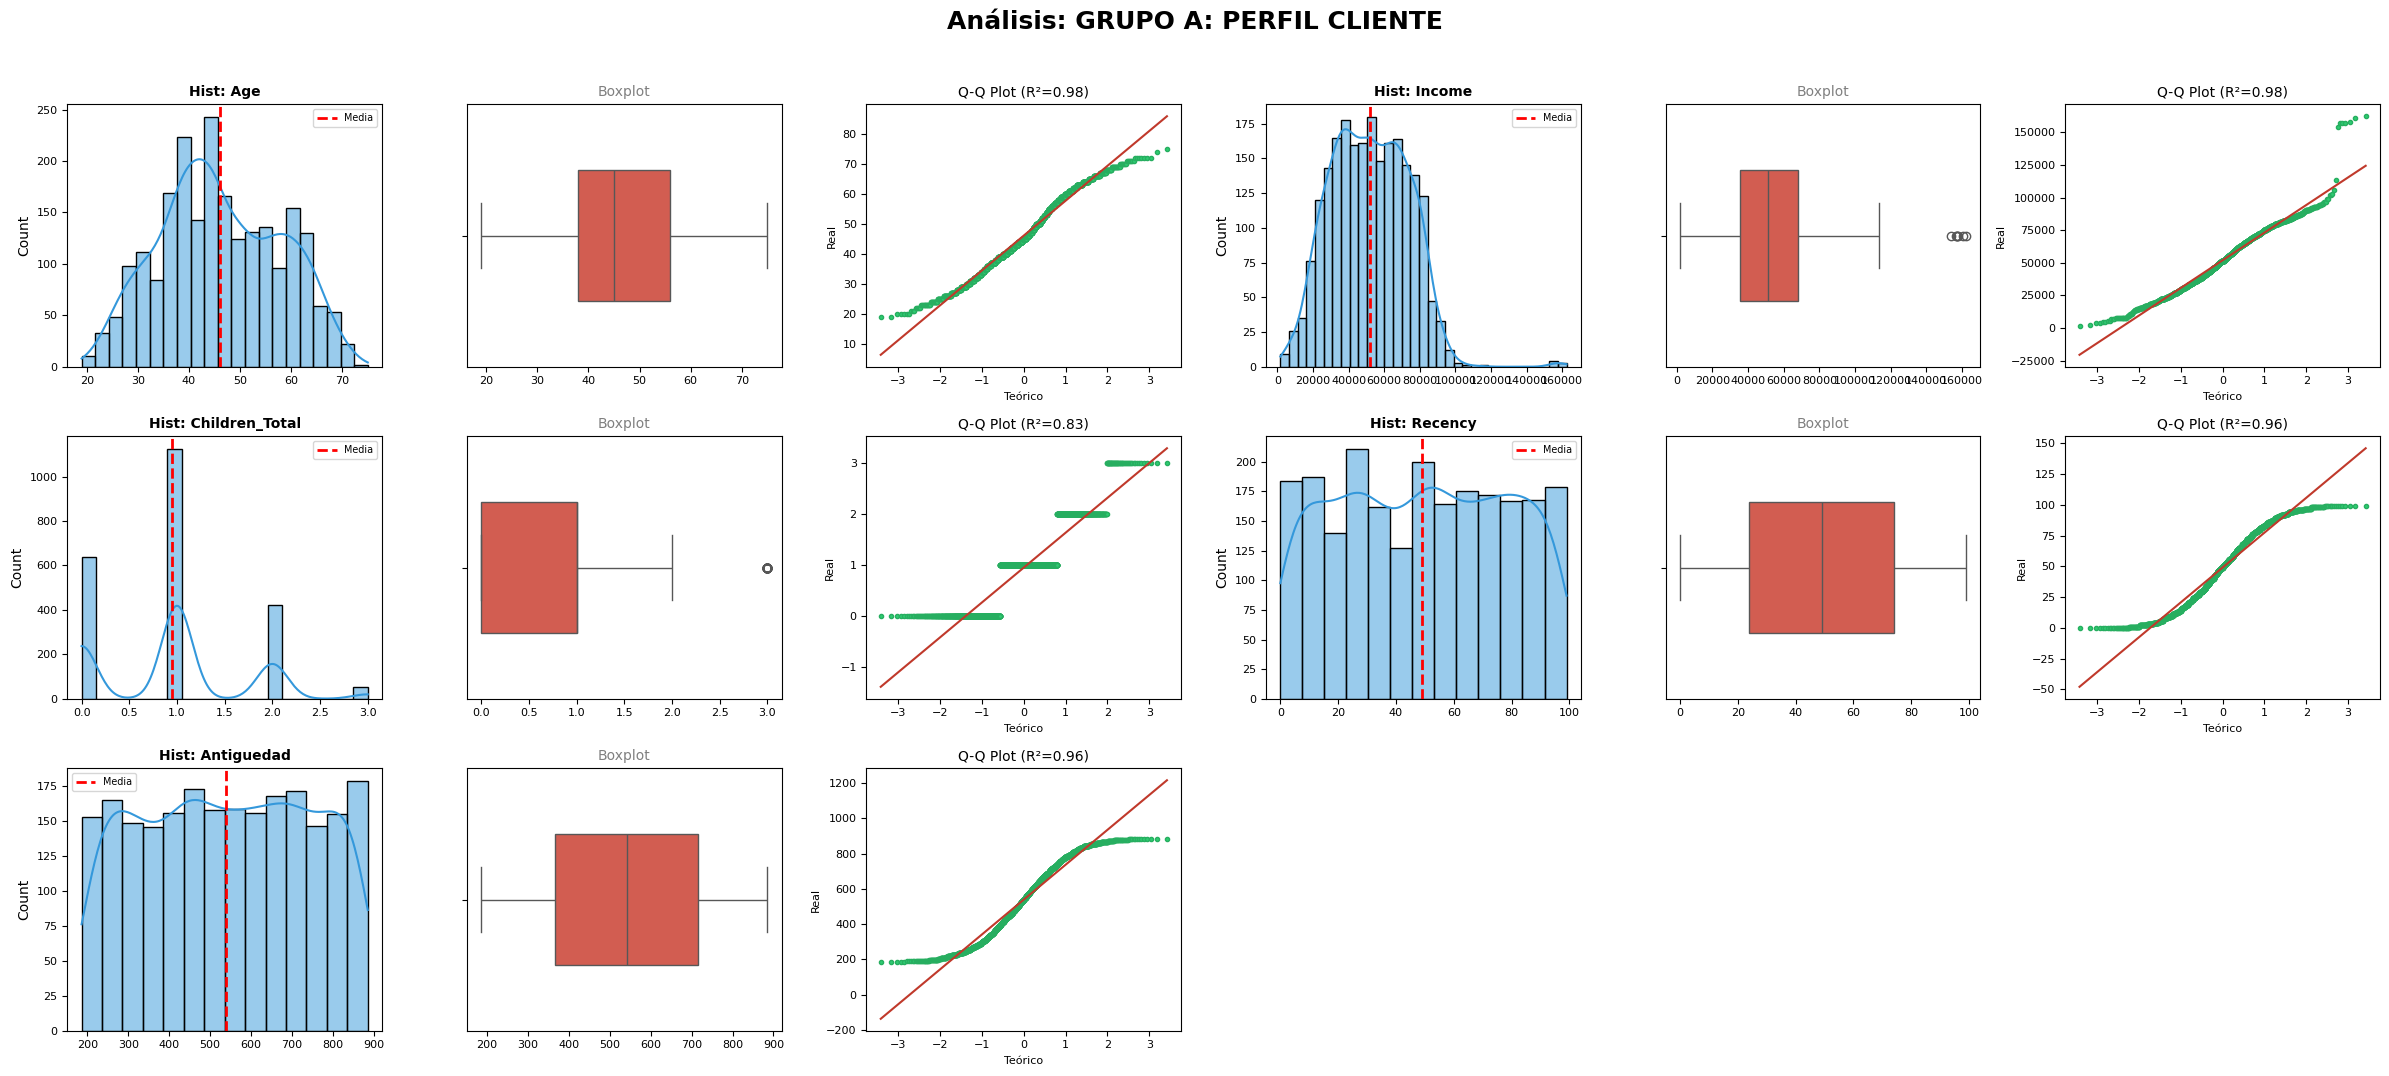

Resumen Estadístico - GRUPO A: PERFIL CLIENTE


,Variable,Media,Mediana,Std,Skew,Kurt,Shapiro p
0,Age,46.10,45.0,11.70,0.09,-0.80,1.7e-15
1,Income,51952.61,51381.5,21411.47,0.35,0.76,6.2e-19
2,Children_Total,0.95,1.0,0.75,0.42,-0.25,1.1e-43
3,Recency,49.12,49.0,28.96,-0.00,-1.20,5.9e-26
4,Antiguedad,539.77,542.0,202.18,-0.02,-1.20,7.7e-26


In [14]:
analizar_grupo("GRUPO A: PERFIL CLIENTE", vars_num_perfil, df_clean)

#### **Análisis del Grupo A: PERFIL CLIENTE**

Identificamos tres patrones estadísticos claros:

1. **Variables Normales (`Age` e `Income`):**
    * Ambas presentan una simetría robusta (`Skewness` < 0.5) y un ajuste visual excelente a la normalidad en el Q-Q Plot ($R^2 = 0.98$).
    * La leve cola superior es natural en salarios; el bajo skewness (0.35) confirma que la limpieza de outliers (>200k) fue exitosa.
2. **Variable Discreta (`Children_Total`):**
    * Muestra un comportamiento discreto (números enteros), visible en los "escalones" del Q-Q Plot.
    * La media de **0.95** y la mediana de **1.0** indican que el cliente estándar tiene un hijo. La distribución es bastante equilibrada (Skewness 0.42), sin sesgos extremos hacia familias muy numerosas.
3. **Variables Uniformes (`Recency` y `Antiguedad`):**
    * Se caracterizan por histogramas planos y una **curtosis negativa** ($\approx -1.20$). Esto indica una frecuencia constante de visitas y altas de clientes a lo largo del tiempo, sin estacionalidad marcada ni picos anómalos.

**Conclusiones y Decisiones:**
* **Falso Positivo de Shapiro:** Debido al tamaño de la muestra ($N > 2200$), ignoramos el p-value de Shapiro (demasiado estricto) y aceptamos la normalidad operativa de *Age* e *Income*.
* **Escalado Obligatorio:** Dada la disparidad de magnitudes (Hijos $\approx$ 1 vs Ingresos $\approx$ 52k), será imprescindible aplicar **`StandardScaler`** antes del Clustering para que los ingresos no dominen el cálculo de distancias.

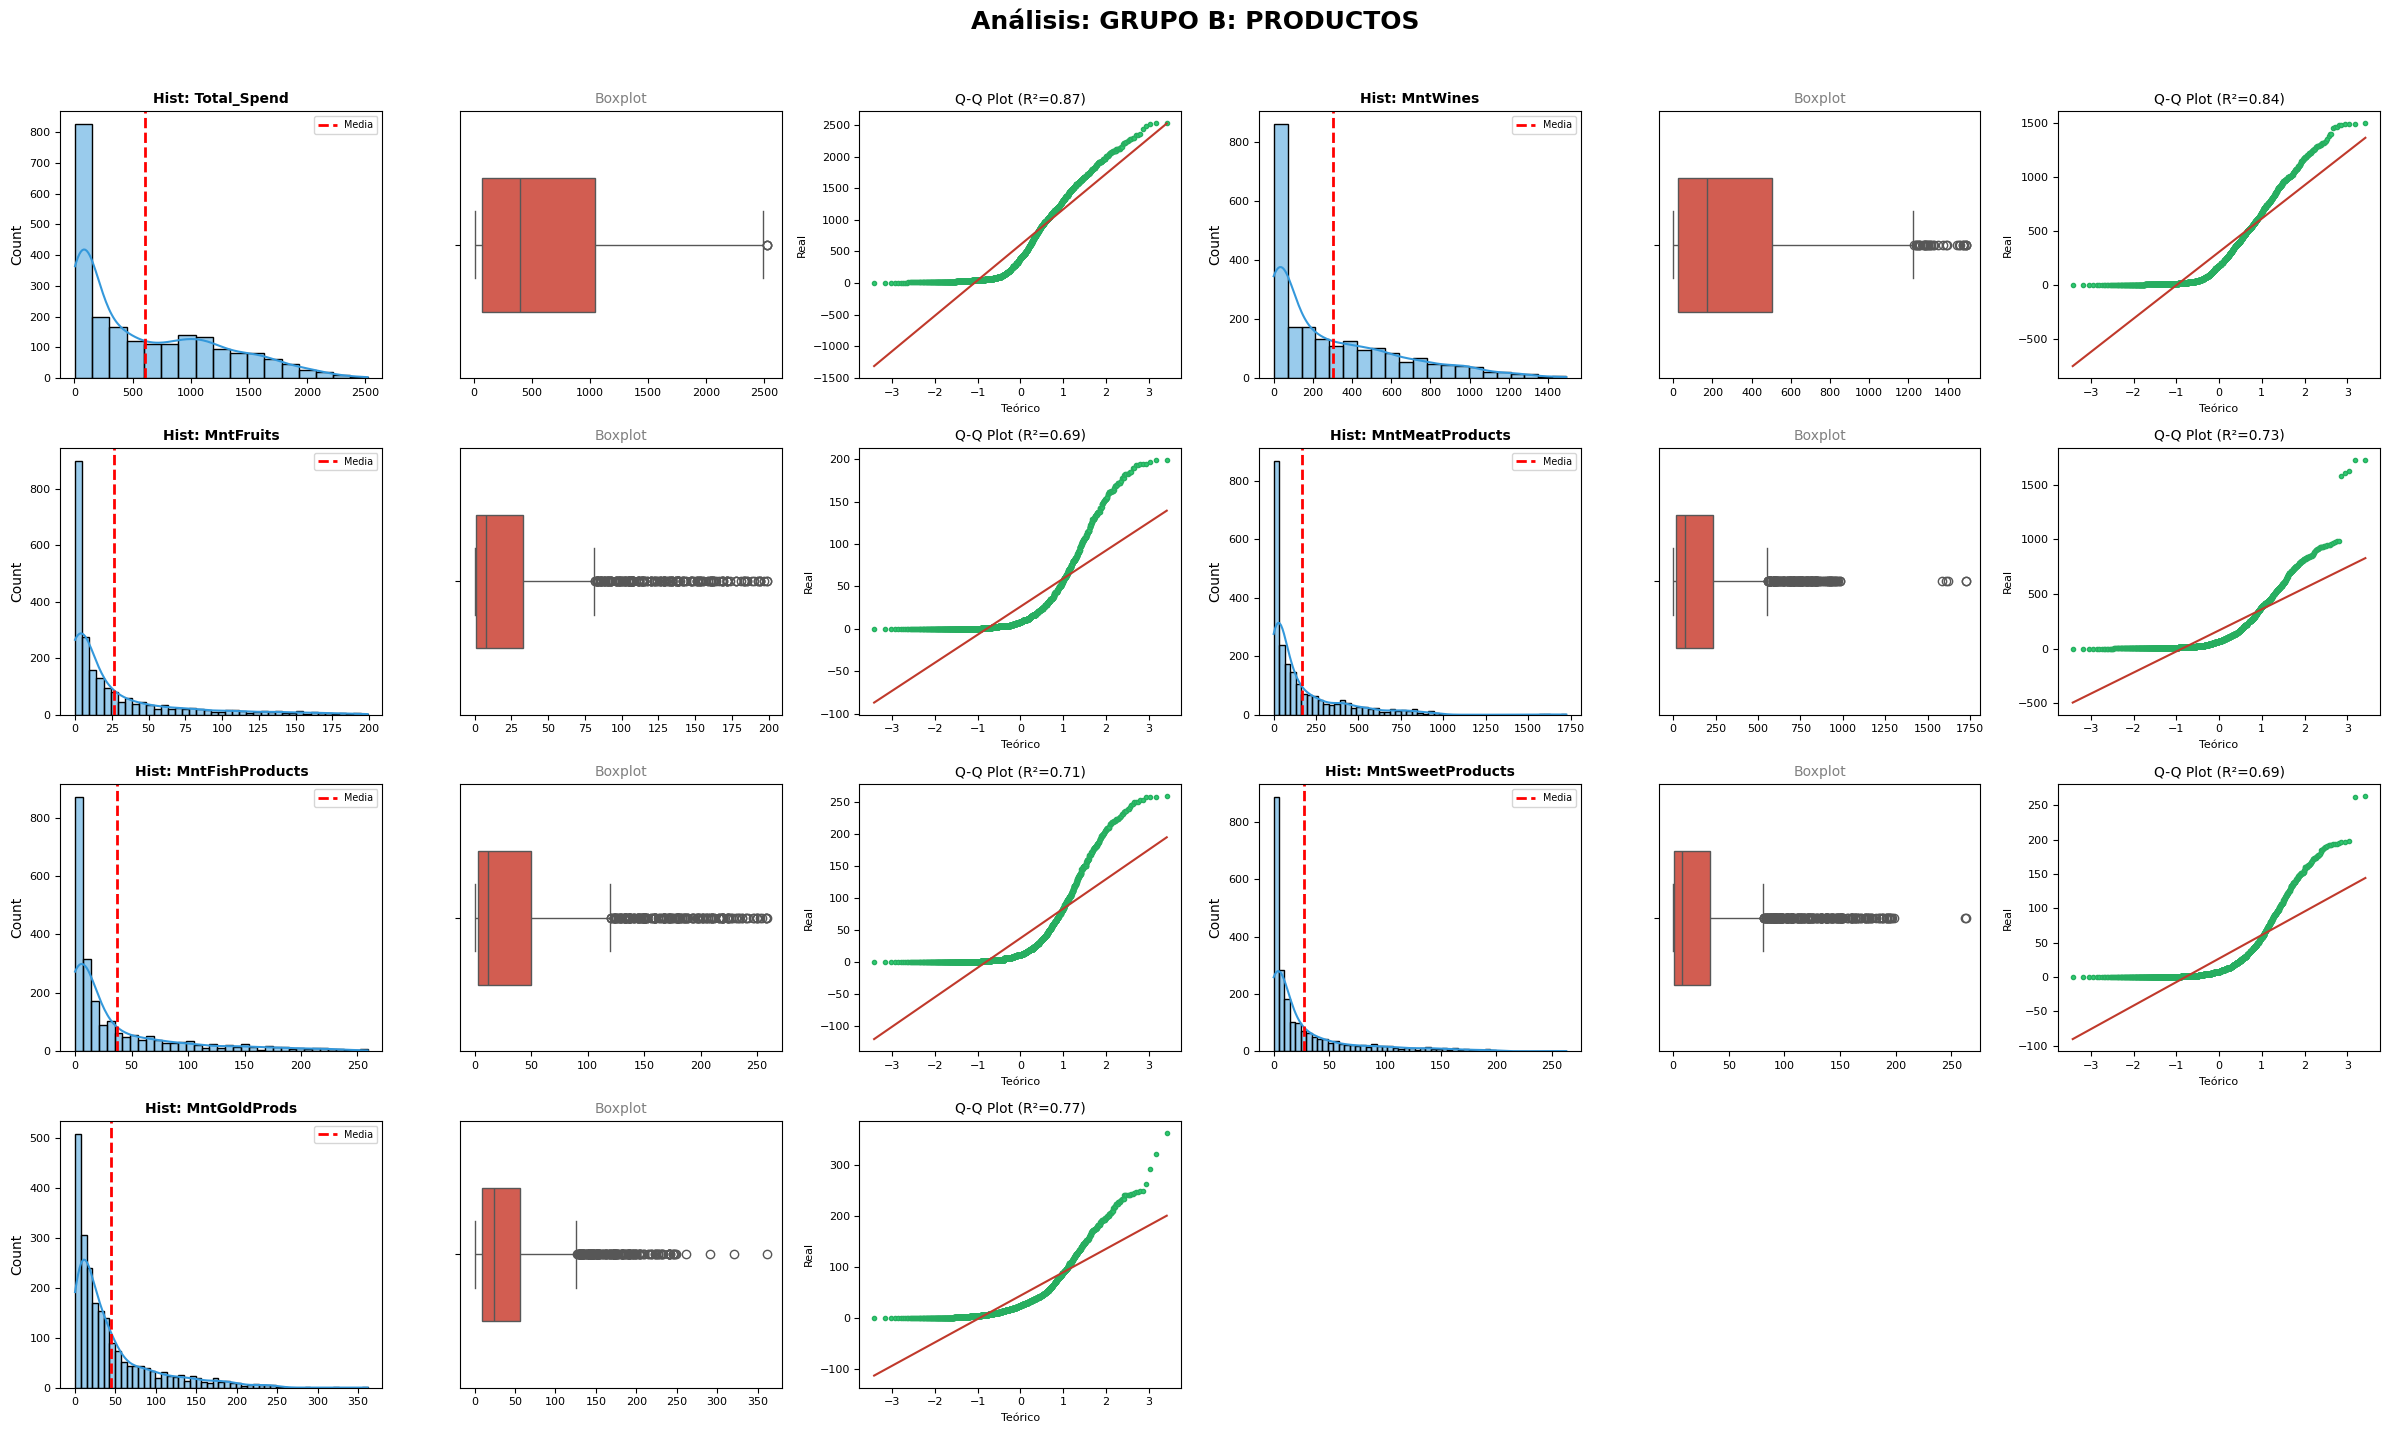

Resumen Estadístico - GRUPO B: PRODUCTOS


,Variable,Media,Mediana,Std,Skew,Kurt,Shapiro p
0,Total_Spend,605.99,396.5,601.87,0.86,-0.34,3.3e-40
1,MntWines,304.13,174.0,336.59,1.18,0.60,6.4e-43
2,MntFruits,26.28,8.0,39.72,2.10,4.07,1.7e-53
3,MntMeatProducts,166.98,67.0,225.69,2.09,5.53,4.0e-51
4,MntFishProducts,37.54,12.0,54.65,1.92,3.10,2.1e-52
5,MntSweetProducts,27.08,8.0,41.30,2.14,4.37,1.2e-53
6,MntGoldProds,43.98,24.0,52.06,1.89,3.56,1.2e-48


In [15]:
analizar_grupo("GRUPO B: PRODUCTOS", vars_num_productos, df_clean)

#### **Análisis del Grupo B: PRODUCTOS (Comportamiento de Gasto)**

A diferencia de las variables demográficas, las variables de consumo (`Total_Spend`, `MntWines`, etc.) muestran un patrón sistemático de **Asimetría Positiva Extrema**. No estamos ante una campana de Gauss, sino ante una distribución de "ley de potencial", típica en datos transaccionales.

**1. Diagnóstico Visual:**
* **Histogramas:** Todos tienen forma de "tobogán". La inmensa mayoría de las observaciones se acumulan a la izquierda (gasto bajo o nulo), con una cola muy larga hacia la derecha.
* **Q-Q Plots:** Si nos fijamos en la curva convexa tan pronunciada de los puntos verdes. Se alejan totalmente de la línea roja desde el principio. Los coeficientes $R^2$ bajan drásticamente (**0.69 - 0.87**). Esto es la prueba visual de la No-Normalidad.
* **Boxplots:** Las "cajas" están aplastadas contra el cero y vemos una nube densa de puntos negros a la derecha. En este contexto, estos outliers NO son ruido ni errores; son los Clientes VIP que sostienen la facturación de la empresa. Eliminarlos sería un error de negocio grave.

**2. Análisis de Métricas Clave:**
* **Disparidad Media vs. Mediana:**
* En todas las categorías, la **Media es muy superior a la Mediana**.
    * *Ejemplo Vinos (`MntWines`):* El promedio es **304**, pero el 50% de los clientes gasta menos de **174**.
    * *Ejemplo Fruta (`MntFruits`):* El promedio es **26**, pero la mediana es solo **8**.
    * Unos pocos clientes que gastan mucho "inflan" el promedio. El cliente "típico" gasta poco en frescos y dulces, concentrando su presupuesto en **Vino y Carne**.
* **Asimetría (Skewness) y Curtosis:**
    * **Skewness > 1.0 (e incluso > 2.0):** Confirma el sesgo extremo a la derecha. Incluso la variable agregada `Total_Spend` mantiene un skewness alto (0.86).
    * **Curtosis Elevada:** Variables como `MntMeatProducts` (Curtosis = 5.53) o `MntSweet` (4.37) indican "colas muy pesadas". La probabilidad de encontrar gastos extremos es mucho mayor que en una distribución normal.

**3. Conclusiones y Decisiones de Modelado:**
1. **Rechazo Total de Normalidad:** Los p-values de Shapiro (todos $< 1e^{-40}$) confirman matemáticamente lo que vemos en los QQPlots: estas variables no son normales bajo ningún estándar.
2. **Jerarquía de Productos:** Los datos revelan que el negocio se sostiene sobre dos pilares: **Vinos y Carnes** (tienen las medianas y rangos más altos). El resto (Fruta, Pescado, Oro) son compras de nicho o complementarias.
3. **Tratamiento Obligatorio:**
    * Para algoritmos sensibles a la distancia (K-Means, KNN), estas variables sesgarán el modelo si se usan tal cual, ya que las distancias de los VIPs dominarán los clústeres.
    * Será necesario aplicar una transformación para "comprimir" estas colas y acercarlas a una distribución normal, como la Transformación Logarítmica (`np.log1p`) antes de escalar los datos.

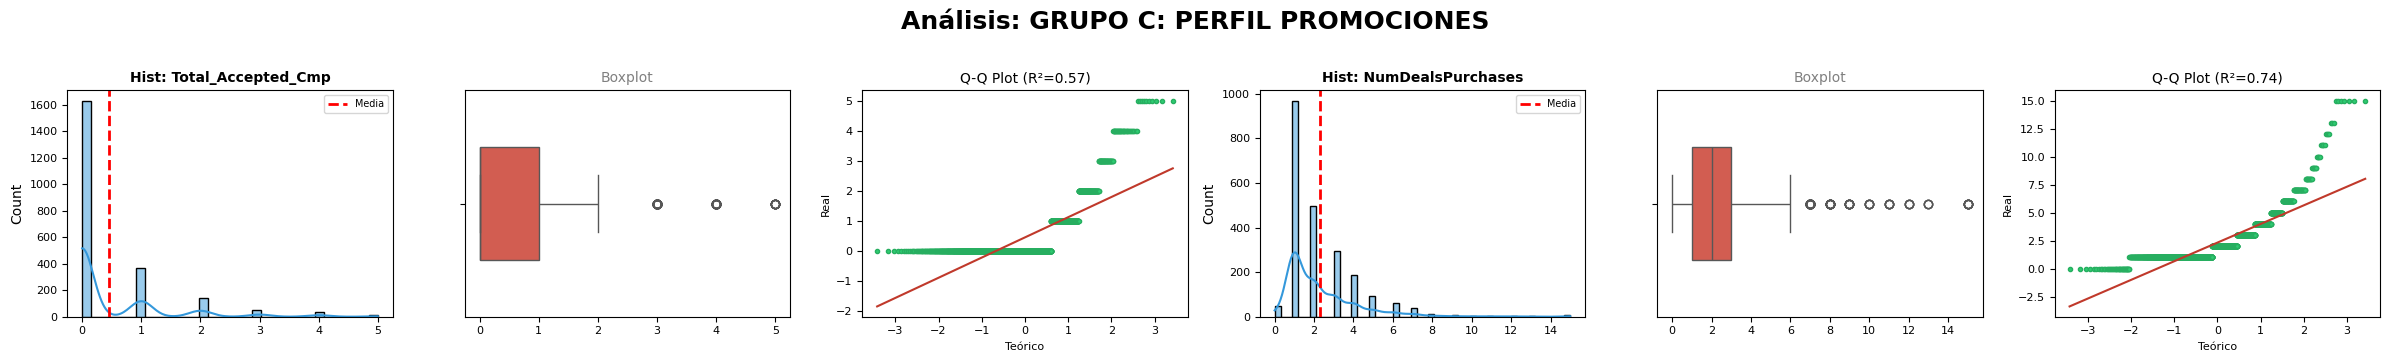

Resumen Estadístico - GRUPO C: PERFIL PROMOCIONES


,Variable,Media,Mediana,Std,Skew,Kurt,Shapiro p
0,Total_Accepted_Cmp,0.45,0.0,0.89,2.44,6.33,2.5e-59
1,NumDealsPurchases,2.33,2.0,1.93,2.42,8.93,1.7e-50


In [16]:
analizar_grupo("GRUPO C: PERFIL PROMOCIONES", vars_num_promo, df_clean)

#### **Análisis del Grupo C: PROMOCIONES (Engagement vs. Oportunidad)**

El análisis de este grupo nos muestra dos caras muy distintas de la interacción cliente-empresa: la **Fidelidad de Marca** (`Accepted_Cmp`) y la **Sensibilidad al Precio** (`Deals`). Ambas presentan distribuciones altamente sesgadas y discretas.

**1. `Total_Accepted_Cmp`: La Realidad del "Engagement" (Fidelidad)**
* **El Dominio del Cero:**
    * La Mediana es **0** y la Media es bajísima (**0.45**).
    * El histograma muestra una barra gigante en el 0. Esto significa que **la inmensa mayoría de los clientes ignora las campañas de marketing**. Es un comportamiento de "cero-inflado".
* **Los Outliers son los "Héroes":**
    * En este caso, los valores atípicos (1, 2, 3, 4, 5) que vemos en el Boxplot **NO son errores**.
    * Aunque estadísticamente son "raros" (Skewness 2.44, Kurtosis 6.33), para el negocio son el segmento más valioso. Estos "Super Fans" que aceptan múltiples campañas son los clientes más comprometidos y rentables.
* **No-Normalidad:** El Q-Q Plot escalonado y con un $R^2$ de 0.57 confirma que es una variable discreta que no sigue ninguna distribución normal.

**2. `NumDealsPurchases`: Los "Cazadores de Ofertas"**
* **Comportamiento de Nicho:**
    * Aunque la mediana es **2 compras** con descuento, la **Kurtosis extrema (8.93)** y el **Skewness (2.42)** nos avisan de una cola muy larga a la derecha.
    * Esto indica que existe un grupo de usuarios intensivos que compran sistemáticamente solo cuando hay ofertas (valores de 5 a 15 en el eje X).
* **Diferencia con Fidelidad:**
    * Es crucial notar que aceptar campañas (fidelidad) y buscar ofertas (precio) son comportamientos distintos. Un cliente puede tener `Deals` alto y `Accepted_Cmp` bajo (un cliente que solo compra rebajas y no le interesa la marca en sí).

**Conclusión Estratégica para el Modelo:**
   * Estas variables actuarán como **"separadores de nicho"** en el algoritmo de K-Means.
   * Mientras que las variables de Gasto (Grupo B) separan por "Poder Adquisitivo", estas variables (Grupo C) separarán por **"Actitud Psicológica"** (¿Le gusta la marca o le gusta el precio?).
   * Al ser variables de conteo con muchos ceros y colas largas, se beneficiarán enormemente de un escalado robusto, aunque su naturaleza discreta siempre generará clústeres muy marcados.

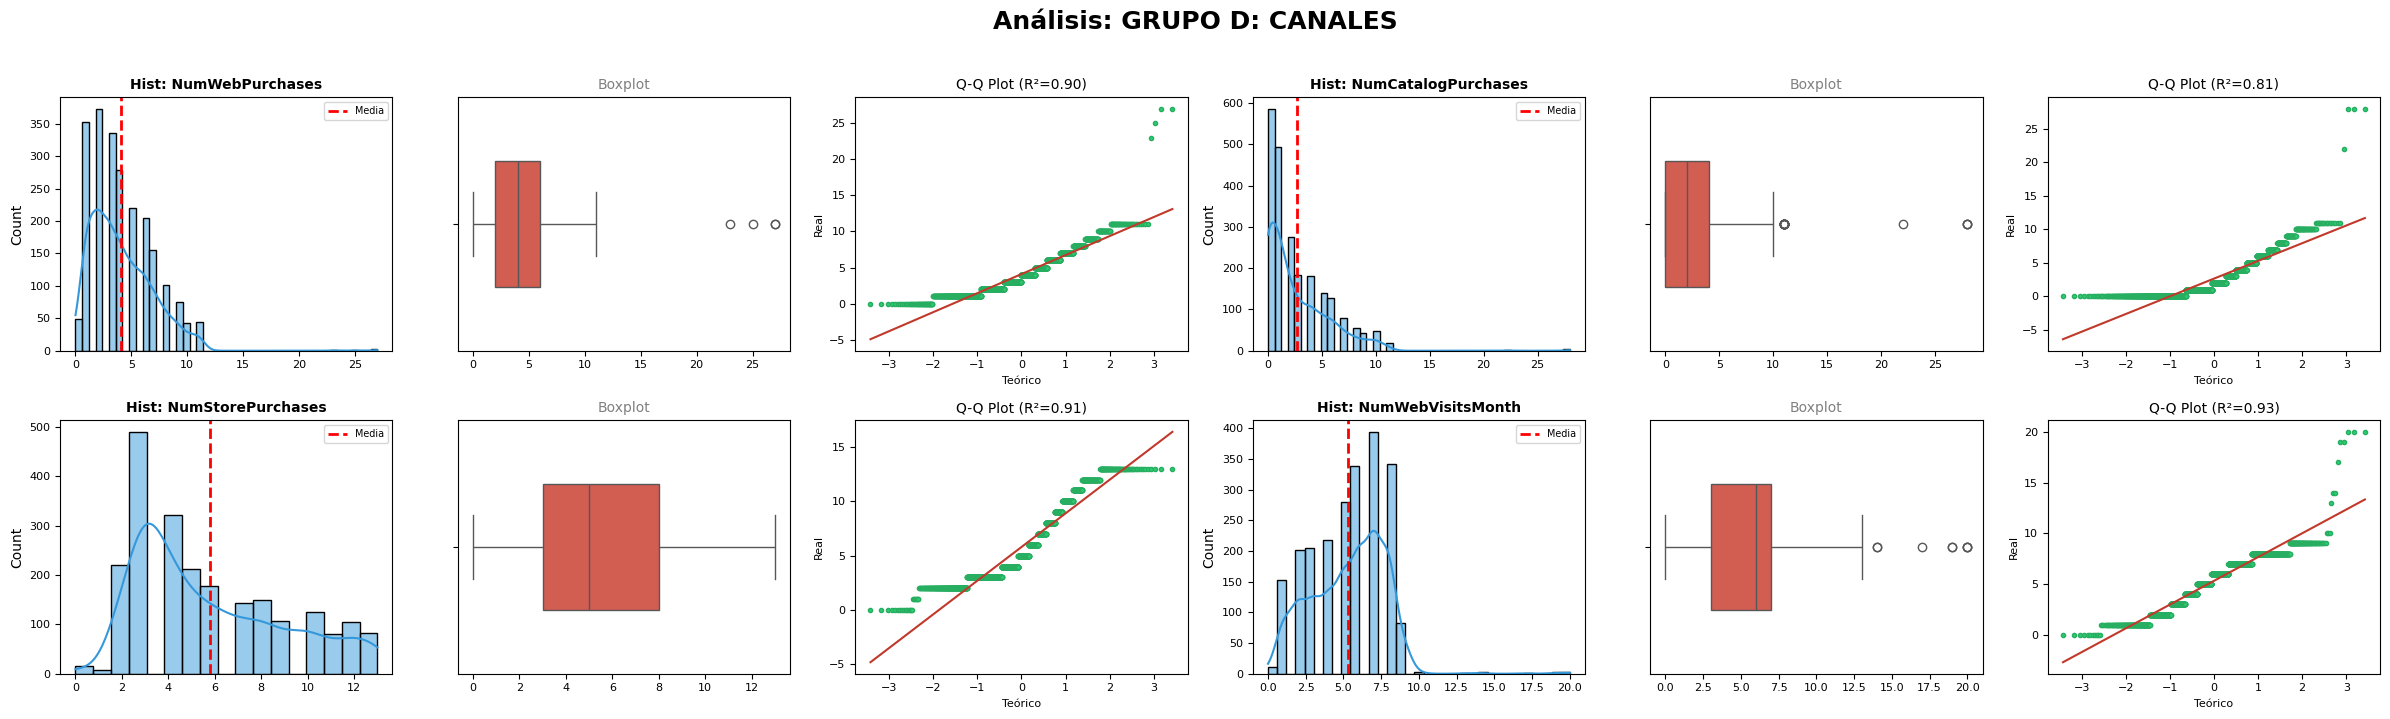

Resumen Estadístico - GRUPO D: CANALES


,Variable,Media,Mediana,Std,Skew,Kurt,Shapiro p
0,NumWebPurchases,4.09,4.0,2.78,1.38,5.70,3.4e-36
1,NumCatalogPurchases,2.66,2.0,2.92,1.88,8.05,5.2e-45
2,NumStorePurchases,5.80,5.0,3.25,0.70,-0.62,3.0e-35
3,NumWebVisitsMonth,5.32,6.0,2.43,0.21,1.82,3.6e-31


In [17]:
analizar_grupo("GRUPO D: CANALES", vars_num_canales, df_clean)

#### **Análisis del Grupo D: CANALES (Comportamiento de Compra)**

En este grupo analizamos la frecuencia de uso de los distintos puntos de contacto. Los datos presentan un comportamiento híbrido entre la normalidad y la asimetría de nicho.

**1. Tienda Física vs. Digital (La Batalla de los Canales):**
* **`NumStorePurchases` (La Reina):**
    * Es el canal dominante con la media más alta (**5.80** compras).
    * **Visualmente:** Es la distribución más "aplanada" (Kurtosis negativa de **-0.62**). Esto es muy relevante: indica que el uso de la tienda física es **democrático y generalizado**. No hay un pico agudo; una gran variedad de clientes compra entre 3 y 8 veces.
    * **Skewness (0.70):** Es moderado. Aunque no es normal perfecta, es la variable de compra más equilibrada del dataset.
* **`NumWebPurchases` (El Aspirante):**
    * Media de **4.09**. Tiene una forma más "picuda" y sesgada (Skew 1.38, Kurtosis 5.70) que la tienda.
    * Esto sugiere que, aunque mucha gente compra online, existe un grupo más específico de compradores digitales intensivos (la cola derecha) que eleva la curtosis.

**2. El Canal de Nicho (Catálogo):**
* **`NumCatalogPurchases`:**
    * **Comportamiento Exclusivo:** Tiene la media más baja (**2.66**) pero la **Kurtosis más alta del grupo (8.05)**.
    * La inmensa mayoría de clientes apenas usa este canal (barras altas en 0, 1 o 2). Sin embargo, la curtosis extrema nos avisa de que existen "Heavy Users" del catálogo que lo usan masivamente (outliers llegando a 28 compras). Es un canal de nicho puro.

**3. Visitas Web (`NumWebVisitsMonth`):**
* **La "Casi Normal" del grupo:**
    * Junto con la Edad, esta variable es la que mejor comportamiento estadístico presenta.
    * **Skewness (0.21):** Es casi simétrica. La media (5.3) y mediana (6.0) están muy cerca.
    * El tráfico web es constante y predecible. La gente entra a mirar ("Window Shopping") de forma regular, independientemente de si acaban comprando mucho o poco.

**Observación Técnica:**
Los Q-Q Plots (especialmente en *WebVisits* o *StorePurchases*), los puntos verdes forman escaleras. Como otra vez esto indica que son variables discretas (números enteros), no continuas.
* Esto hace que el test de Shapiro falle siempre (p-value minúsculo), pero visualmente confirmamos que `NumWebVisitsMonth` y `NumStorePurchases` son lo suficientemente robustas para trabajar sin transformaciones agresivas.

**Resumen:**
"La Tienda Física es el canal principal y más transversal (uso generalizado). El Catálogo es un canal de nicho con usuarios muy intensivos. Las visitas web siguen un patrón normal, lo que sugiere un tráfico digital saludable y predecible que funciona como paso previo a la compra (ROPO)."

### Análisis Bivariante: Relaciones y Drivers de Negocio

Una vez entendidas las variables por separado, el siguiente paso crítico es analizar **cómo interactúan entre sí**. Nuestro objetivo es descubrir qué factores impulsan el gasto (`Total_Spend`) y la fidelidad (`Total_Accepted_Cmp`).

Para generar una **Matriz de Correlación** legible y estratégica, hemos seleccionado un subconjunto específico de variables clave en lugar de utilizar el dataset completo.

**Criterios de Selección de Variables:**
1. **Visión Agregada (Macro):** Utilizamos las variables resumen creadas (`Total_Spend`, `Children_Total`, `Total_Accepted_Cmp`) en lugar de sus componentes individuales. Esto evita la **redundancia estadística** (obviedades como que "gastar más en vino aumenta el gasto total") y nos permite centrarnos en las relaciones estructurales.
2. **Focus en KPIs de Negocio:** Incluimos métricas financieras (`Income`), demográficas (`Age`), de comportamiento (`Recency`, `Antigüedad`) y de canal (`Web`, `Store`, `Catalog`) para tener una visión 360º del cliente.
3. **Limpieza Visual:** Excluimos identificadores (`ID`) y variables binarias desagregadas para asegurar que el mapa de calor revele los patrones fuertes sin "ruido" visual.

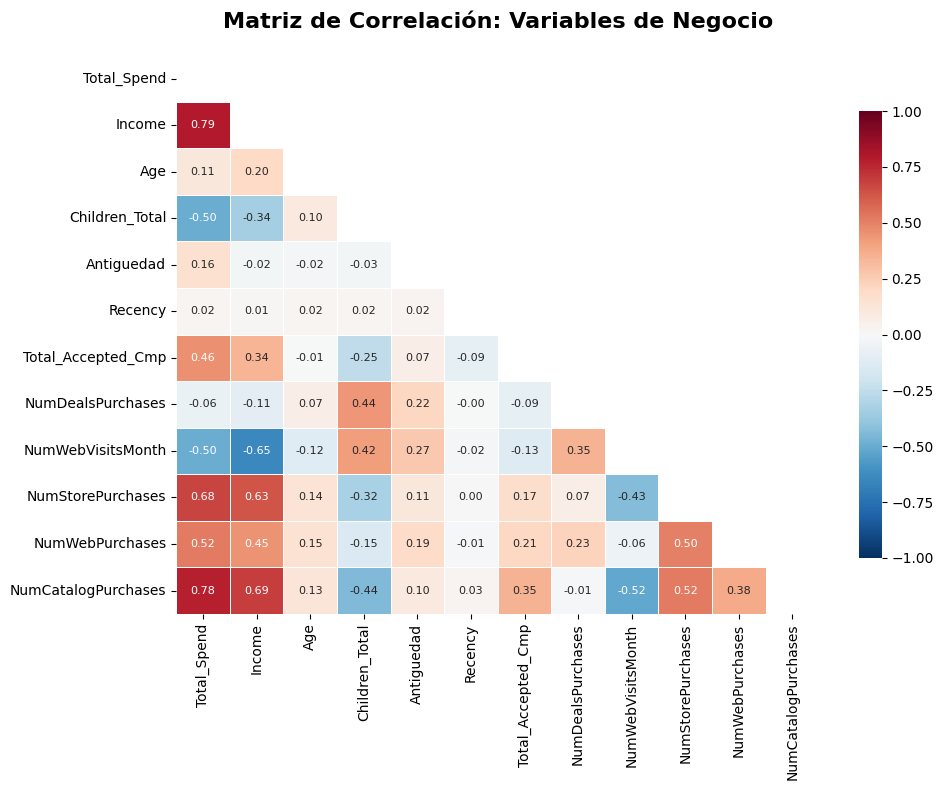

In [18]:
cols_corr = [
    'Total_Spend', 'Income', 'Age', 'Children_Total',
    'Antiguedad', 'Recency',
    'Total_Accepted_Cmp', 'NumDealsPurchases',
    'NumWebVisitsMonth', 'NumStorePurchases', 'NumWebPurchases', 'NumCatalogPurchases'
]

corr_matrix = df_clean[cols_corr].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='RdBu_r',
            mask=mask,
            linewidths=0.5,
            vmin=-1, vmax=1,
            cbar_kws={"shrink": .8},
            annot_kws={"size": 8})

plt.title("Matriz de Correlación: Variables de Negocio", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

#### **Análisis Bivariante: Matriz de Correlación**

El Mapa de Calor revela las conexiones fundamentales que impulsan el negocio. Destacamos cuatro dinámicas críticas para la segmentación:

**1. El Motor Económico (`Income` vs `Total_Spend`):**
* Existe una correlación positiva muy fuerte (**0.79**).
* Como era de esperar, el poder adquisitivo es el predictor principal del gasto. Sin embargo, no es el único factor.

**2. La Sorpresa del Canal: El Poder del Catálogo (`NumCatalogPurchases`):**
* Esta variable presenta una correlación de **0.78** con el Gasto Total, prácticamente idéntica a la de los Ingresos.
* A diferencia de lo que se podría pensar en un entorno digital, **el Catálogo es el canal de los clientes VIP**. Quienes compran por catálogo gastan masivamente, mientras que la correlación con la Web es mucho menor (0.52).

**3. La Paradoja Digital (`NumWebVisitsMonth`):**
* Presenta una correlación **negativa fuerte** con los Ingresos (**-0.65**) y con el Gasto (**-0.50**).
* Se confirma el patrón de "Window Shopping". Los usuarios que más visitan la web suelen ser los de menor poder adquisitivo. Por el contrario, los clientes de alto valor son **eficientes**: visitan poco la web porque compran directamente (probablemente por catálogo o tienda) o saben exactamente lo que quieren.

**4. El "Freno Familiar" (`Children_Total`):**
* Correlación **Negativa** con `Total_Spend` (**-0.50**) y con `Income` (**-0.34**).
* La carga familiar reduce drásticamente el presupuesto para productos de "lujo" (Vino/Oro). Además, la correlación positiva con `NumDealsPurchases` (**0.44**) confirma que las familias son el target principal para las ofertas y descuentos, no para las campañas de exclusividad.

#### **Análisis Visual Detallado: Pairplot**

Una vez que el Mapa de Calor nos ha señalado *dónde* existen relaciones fuertes (por ejemplo, Ingresos vs. Gasto o Hijos vs. Web), utilizamos el **Pairplot** como una "lupa" para inspeccionar la **naturaleza y forma** de dichas conexiones.

El coeficiente de correlación (el número en el Heatmap) es un resumen estadístico que asume linealidad, pero puede esconder matices importantes. El Pairplot nos permite:

1. **Validar la Linealidad:** Confirmar si la relación es una línea recta (ideal para modelos lineales) o si tiene curvas (exponencial, logarítmica) que requieran transformaciones.
2. **Detectar Clusters Naturales:** Al colorear por una variable categórica clave (en este caso `Children_Total`), podemos ver si los grupos se separan visualmente en el espacio, lo cual es un indicio excelente de que el algoritmo de Clustering funcionará bien.
3. **Identificar Patrones de Nicho:** Ver comportamientos que solo ocurren en rangos específicos (ej. "solo la gente muy rica compra por catálogo"), algo que un simple número de correlación no puede explicarnos.

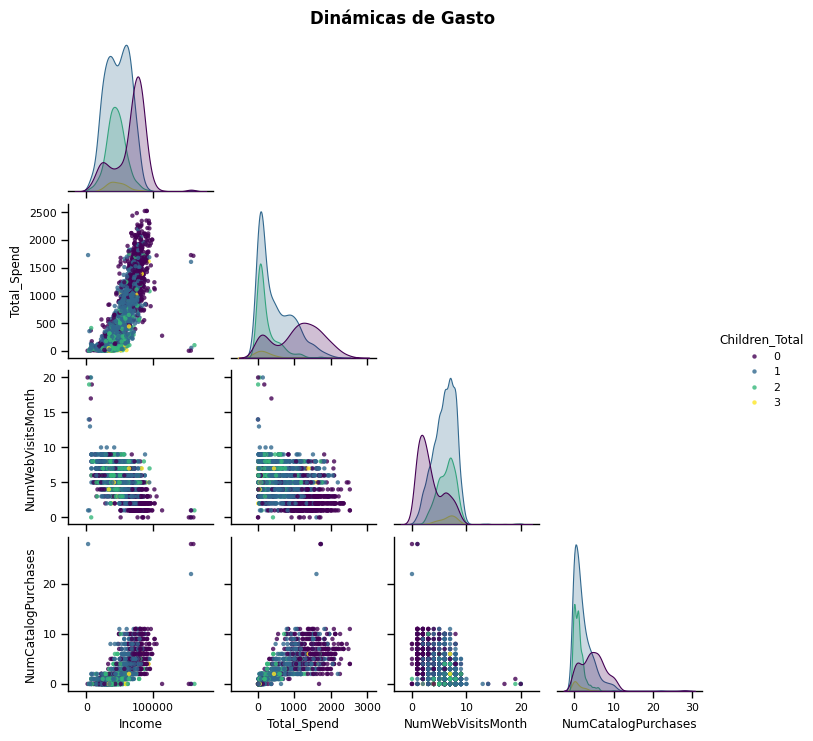

In [19]:
sns.set_context("paper", font_scale=0.9)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100

vars_zoom = ['Income', 'Total_Spend', 'NumWebVisitsMonth', 'NumCatalogPurchases']

sns.pairplot(df_clean[vars_zoom + ['Children_Total']],
             hue='Children_Total',
             palette='viridis',
             corner=True,
             height=1.8,
             aspect=1,
             plot_kws={'alpha': 0.8, 's': 10, 'edgecolor': 'none'})

plt.suptitle("Dinámicas de Gasto", y=1.02, fontsize=12, fontweight='bold')
plt.show()

sns.set_context("notebook")

#### **Análisis Visual Detallado: Dinámicas de Gasto y Familia**

Este gráfico confirma visualmente que la **estructura familiar** es el factor discriminante más potente del dataset. Los colores (0 hijos = Morado, 3 hijos = Amarillo) nos cuentan una historia clara:

**1. La Brecha de Riqueza y Gasto (`Income` vs `Total_Spend`):**
* **El Clúster "Elite" (Puntos Morados - 0 Hijos):** Dominan completamente la esquina superior derecha. Son clientes con altos ingresos (>60k) y gasto masivo. Al no tener carga familiar, su renta disponible se va directa al consumo.
* **El Clúster "Presupuesto Familiar" (Verde/Amarillo - 2 o 3 Hijos):** Están confinados en la esquina inferior izquierda. Aunque sus ingresos suban, su gasto se mantiene bajo ("techo de cristal"). Esto valida la hipótesis de que el dinero se desvía a necesidades básicas no registradas aquí.

**2. El Comportamiento Digital Inverso (`NumWebVisitsMonth`):**
* Miramos el gráfico de densidad (la montaña) en la esquina inferior derecha.
    * **Pico Morado (0 hijos):** Está a la izquierda (0-4 visitas). Visitan poco.
    * **Pico Verde/Amarillo (Familias):** Está a la derecha (6-8 visitas). Visitan mucho.
* Esto confirma visualmente el fenómeno de **"Window Shopping"**. Las familias visitan la web constantemente (probablemente buscando ofertas o comparando precios), mientras que los clientes de alto valor compran de forma eficiente sin navegar tanto.

**3. La Exclusividad del Catálogo (`NumCatalogPurchases`):**
* Observamos el cruce entre `Income` y `Catalog`.
* Tiene forma de **"Palo de Hockey"**. El canal de catálogo es prácticamente inexistente para las familias (puntos amarillos/verdes en el suelo). Solo se activa exponencialmente para los clientes sin hijos y con altos ingresos.

**Conclusión:**
No necesitamos algoritmos complejos para ver que **ya existen grupos separados**.
   * **Grupo A:** Solteros/Parejas ricas (Morado) -> Objetivo de campañas de Lujo/Catálogo.
   * **Grupo B:** Familias numerosas (Amarillo) -> Objetivo de Descuentos/Web.<br>

El Clustering matemático simplemente pondrá una etiqueta formal a esta separación visual que acabamos de detectar.

#### Integración Espacial: Del 2D al 3D

Aunque el Pairplot anterior nos ha mostrado relaciones bidimensionales claras (par a par), la realidad de nuestros clientes es multidimensional.

Para confirmar definitivamente la existencia de grupos separables antes de aplicar el algoritmo de Clustering, generamos una proyección espacial tridimensional combinando las tres variables más críticas coloreando por Estructura Familiar:
* Dinero (Income)
* Gasto (Total_Spend)
* Comportamiento (WebVisits)

Ahora generamos el mismo grafico 3d en 2d para poder visualizarlo en el informe:

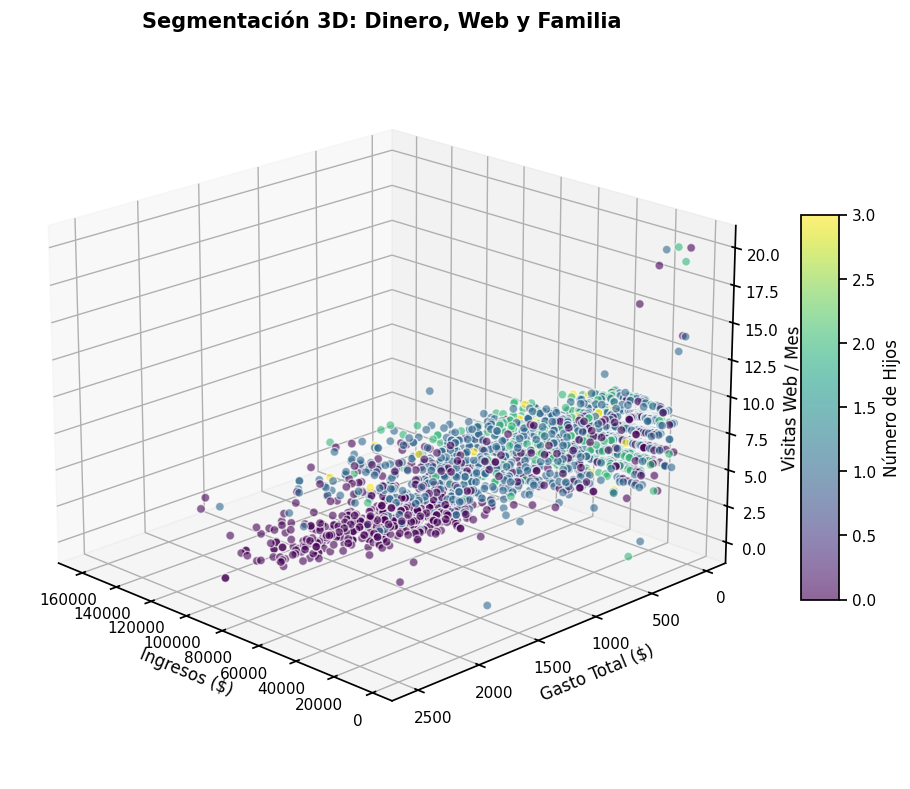

In [21]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

x = df_clean['Income']
y = df_clean['Total_Spend']
z = df_clean['NumWebVisitsMonth']
c = df_clean['Children_Total']

img = ax.scatter(x, y, z, c=c, cmap='viridis', s=40, alpha=0.6, edgecolors='w')

ax.set_xlabel('Ingresos ($)')
ax.set_ylabel('Gasto Total ($)')
ax.set_zlabel('Visitas Web / Mes')
ax.set_title('Segmentación 3D: Dinero, Web y Familia', fontsize=15, fontweight='bold')

cbar = fig.colorbar(img, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('Número de Hijos')

ax.view_init(elev=20, azim=135)

plt.show()

#### **Segmentación Espacial 3D**

La proyección tridimensional revela una topología fascinante que valida todas nuestras hipótesis anteriores. Al observar la nube de puntos, identificamos dos "galaxias" de clientes que ocupan rincones opuestos del espacio comercial:

**1. El Clúster "Eficiente" (Puntos Morados - Sin Hijos):**
   * Se sitúan "a ras de suelo" (eje Z bajo) pero se extienden hacia la derecha y el fondo (altos Ingresos y Gasto).
   * Tienen mucho dinero, gastan mucho, pero **apenas visitan la web**. Son compradores directos. Su posición baja en el eje Z indica que no necesitan navegar intensivamente para tomar decisiones de compra.

**2. El Clúster "Explorador" (Puntos Verdes/Amarillos - Con Hijos):**
   * Forman una nube que "flota" en la parte superior izquierda.
   * Tienen ingresos limitados y bajo gasto, pero **dominan las alturas del eje Z** (muchas visitas web).
   * Esta "nube flotante" representa a las familias que dedican mucho tiempo a navegar, comparar y buscar oportunidades para optimizar su presupuesto.

**Conclusión Final del EDA Numérico:**
La separación espacial es tan nítida que es visible al ojo humano. Los clientes no están mezclados aleatoriamente; existen **fronteras naturales** definidas por el poder adquisitivo y la carga familiar. Esto garantiza que modelos como **K-Means** tendrán un alto rendimiento al trazar estas fronteras matemáticamente.

### Estudio Variables Categóricas
Tras la limpieza del dataset, procedemos a identificar las variables cualitativas (categóricas) resultantes.

A continuación, realizamos un análisis de distribución de frecuencias para cada una de ellas con el objetivo de entender la composición de la muestra, evaluar la cardinalidad de las categorías y detectar posibles desequilibrios en los datos.

In [22]:
dict_categorias = {
    "GRUPO A: PERFIL CLIENTE": vars_cat_perfil,
    "GRUPO C: PROMOCIONES (Binarias)": vars_cat_promo
}

for grupo, cols in dict_categorias.items():
    print(f"\n{'='*50}")
    print(f" {grupo}")

    for col in cols:
        print(f"\n>>> VARIABLE: {col}")

        conteo = df_clean[col].value_counts()
        porcentaje = df_clean[col].value_counts(normalize=True) * 100

        resumen = pd.DataFrame({'Frecuencia': conteo, '% Total': porcentaje.round(2)})
        print(resumen)


 GRUPO A: PERFIL CLIENTE

>>> VARIABLE: Education
            Frecuencia  % Total
Education                      
Graduation        1126    50.36
PhD                485    21.69
Master             370    16.55
2n Cycle           201     8.99
Basic               54     2.42

>>> VARIABLE: Marital_Status
                Frecuencia  % Total
Marital_Status                     
Married                864    38.64
Together               578    25.85
Single                 479    21.42
Divorced               231    10.33
Widow                   77     3.44
Alone                    3     0.13
Absurd                   2     0.09
YOLO                     2     0.09

>>> VARIABLE: Kidhome
         Frecuencia  % Total
Kidhome                     
0              1291    57.74
1               897    40.12
2                48     2.15

>>> VARIABLE: Teenhome
          Frecuencia  % Total
Teenhome                     
0               1155    51.65
1               1029    46.02
2                 52   

#### **Análisis de Variables Categóricas**
La inspección de frecuencias revela problemas de calidad de datos ("Etiquetas Basura") y oportunidades de simplificación para mejorar el rendimiento del modelo.

**1. Perfil Demográfico (Grupo A):**
* **Educación (`Education`):**
    * La mitad de la base (50%) son Graduados universitarios.
    * Existe la categoría `2n Cycle` (8.99%) y `Master` (16.55%). En la práctica, un "Segundo Ciclo" equivale académicamente a una Maestría. Mantenerlas separadas diluye la información.
    * Fusionaremos `2n Cycle` dentro de `Master` para crear una categoría de "Postgrado" más robusta.
* **Estado Civil (`Marital_Status`):**
    * **Dominio de Parejas:** El 64% de los clientes vive en pareja (`Married` + `Together`).
    * **Datos "Basura":** Hemos detectado 3 categorías absurdas con frecuencia irrelevante: `Alone` (3 casos), `Absurd` (2 casos) y `YOLO` (2 casos). Estos 7 registros representan "ruido" puro.
    * Reemplazaremos estas etiquetas por `Single`, ya que representan a personas sin pareja declarada.
* **Quejas (`Complain`):**
    * **Varianza Cero:** El 99.11% de los valores son "0". Solo existen 20 quejas en todo el histórico.
    * Esta variable **no aporta información** para segmentar (no discrimina). Se eliminará del dataset para reducir ruido dimensional.

**2. Rendimiento de Marketing (Grupo C):**
* **Las Campañas:**
    * La aceptación general es baja, oscilando entre el 6% y el 7%.
    * **La "Oveja Negra":** La campaña `AcceptedCmp2` fue un fracaso notable, con solo un 1.34% de éxito.
    * **La Mejor:** La campaña `AcceptedCmp4` y la `AcceptedCmp3` son las más efectivas (~7.3%).
* **Tasa de Conversión (`Response`):**
    * La última campaña tuvo un éxito del **14.94%**. Este es un dato muy positivo comparado con las campañas anteriores, sugiriendo una mejora en la estrategia reciente.

#### **Ejecución de la Limpieza y Refinamiento**

Basándonos en el diagnóstico anterior, aplicamos las siguientes transformaciones directas sobre `df_clean` para estandarizar las categorías y eliminar el ruido antes del modelado:

1. **Unificación Educativa:** Se fusiona `2n Cycle` dentro de `Master`.
2. **Saneamiento Civil:** Se reasignan las etiquetas minoritarias (`YOLO`, `Absurd`, `Alone`) a la categoría `Single`.
3. **Eliminación de Variables:** Se descartan `Complain` (falta de varianza) y los metadatos ya procesados (`ID`, `Year_Birth`, `Dt_Customer`) que no aportan valor predictivo al algoritmo.

In [23]:
df_clean['Education'] = df_clean['Education'].replace({'2n Cycle': 'Master'})

basura_civil = ['YOLO', 'Absurd', 'Alone']
df_clean['Marital_Status'] = df_clean['Marital_Status'].replace(basura_civil, 'Single')

cols_eliminar = ['Complain', 'ID', 'Dt_Customer', 'Year_Birth']
cols_finales_borrar = [c for c in cols_eliminar if c in df_clean.columns]

df_clean = df_clean.drop(columns=cols_finales_borrar)

print(f"Limpieza completada. Variables eliminadas: {cols_finales_borrar}")
print(f"Dimensiones actuales del dataset: {df_clean.shape}")

Limpieza completada. Variables eliminadas: ['Complain', 'ID', 'Dt_Customer', 'Year_Birth']
Dimensiones actuales del dataset: (2236, 28)


#### Análisis Visual Post-Limpieza de Variables Categóricas
Utilizamos gráficos de barras y boxplots para visualizar la distribución de las variables categóricas del Grupo A (Perfil) y su relación con el Gasto Total tras la limpieza.

Esto nos permite validar visualmente las transformaciones aplicadas y entender mejor cómo cada categoría influye en el comportamiento de gasto.

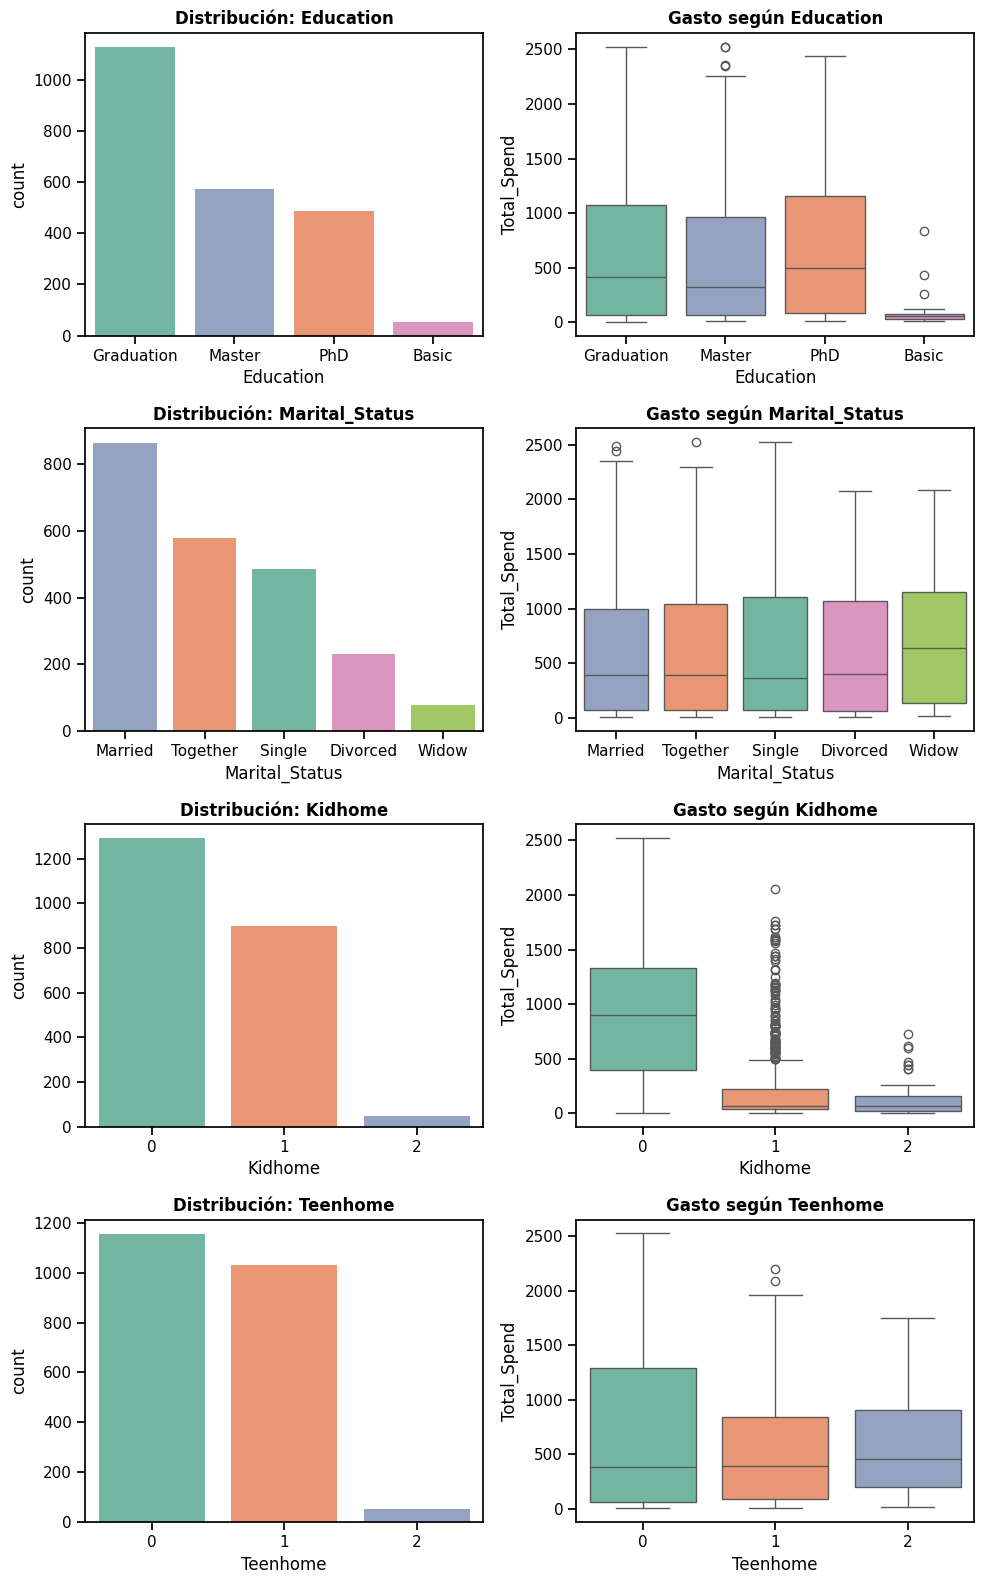

In [24]:
vars_a_graficar = [c for c in vars_cat_perfil if c in df_clean.columns]

fig, axes = plt.subplots(len(vars_a_graficar), 2, figsize=(10, 4 * len(vars_a_graficar)))

for i, col in enumerate(vars_a_graficar):
    sns.countplot(x=col, data=df_clean, ax=axes[i, 0], palette='Set2',
                  hue=col, legend=False, order=df_clean[col].value_counts().index)
    axes[i, 0].set_title(f'Distribución: {col}', fontweight='bold')

    sns.boxplot(x=col, y='Total_Spend', data=df_clean, ax=axes[i, 1], palette='Set2',
                hue=col, legend=False, order=df_clean[col].value_counts().index)
    axes[i, 1].set_title(f'Gasto según {col}', fontweight='bold')

plt.tight_layout()
plt.show()

#### **Análisis Visual del Perfil Demográfico**

La visualización consolida las variables categóricas del **Grupo A (Perfil)** tras la limpieza, revelando qué características definen al cliente de alto valor.

**1. Nivel Educativo (`Education`):**
* **Distribución:** La categoría `Graduation` (Licenciados) es la predominante. La fusión de `Master` y `2n Cycle` ha creado un segundo grupo sólido de postgraduados.
* **Comportamiento de Gasto:**
    * **El segmento "Basic" es de bajo valor:** Su caja de gasto está pegada a cero. Estos clientes tienen muy poco potencial de monetización.
    * Los clientes con `PhD` son los que más gastan. Su mediana es ligeramente superior a la de `Graduation` y `Master`.

**2. Estado Civil (`Marital_Status`):**
* **Limpieza Exitosa:** La categoría `Single` aparece limpia y consistente, habiendo absorbido los valores atípicos.
* **Irrelevancia en el Gasto:** Este es un hallazgo clave. Al observar los boxplots, las medianas de gasto son **sorprendentemente similares** entre `Married`, `Together`, `Single` y `Divorced`.
    * `Widow` (viudos) muestra una caja ligeramente más alta, pero con muy pocos datos.
* El estado civil **NO** es una variable discriminante fuerte para predecir el gasto. Un soltero gasta de forma muy similar a un casado en este negocio.

**3. El Verdadero Freno: Los Hijos (`Kidhome`):**
* **Impacto Brutal:** Esta variable muestra la diferencia más drástica de todo el dataset.
    * **0 Niños:** La caja es alta y amplia (Mediana de gasto > 1000 aprox).
    * **1 Niño:** El gasto colapsa dramáticamente.
* La presencia de un niño pequeño actúa como un "ancla" financiera, pensamos que desvía recursos hacia necesidades no reflejadas en este dataset (educación, salud, ocio infantil). También podria ser para ahorrar para el futuro del niño.

**4. Adolescentes (`Teenhome`):**
* **Impacto Moderado:** Tener adolescentes también reduce el gasto comparado con no tenerlos (0), pero la caída es **menos severa** que con los niños pequeños.
* Esto sugiere que a medida que los hijos crecen, el presupuesto familiar recupera cierto margen para el consumo, aunque no vuelve a los niveles de "sin hijos".

#### Análisis Visual de Variables Categóricas del Grupo C (Promociones)
Similarmente, visualizamos las variables categóricas del Grupo C (Promociones) para entender cómo la aceptación de campañas pasadas influye en el gasto total.

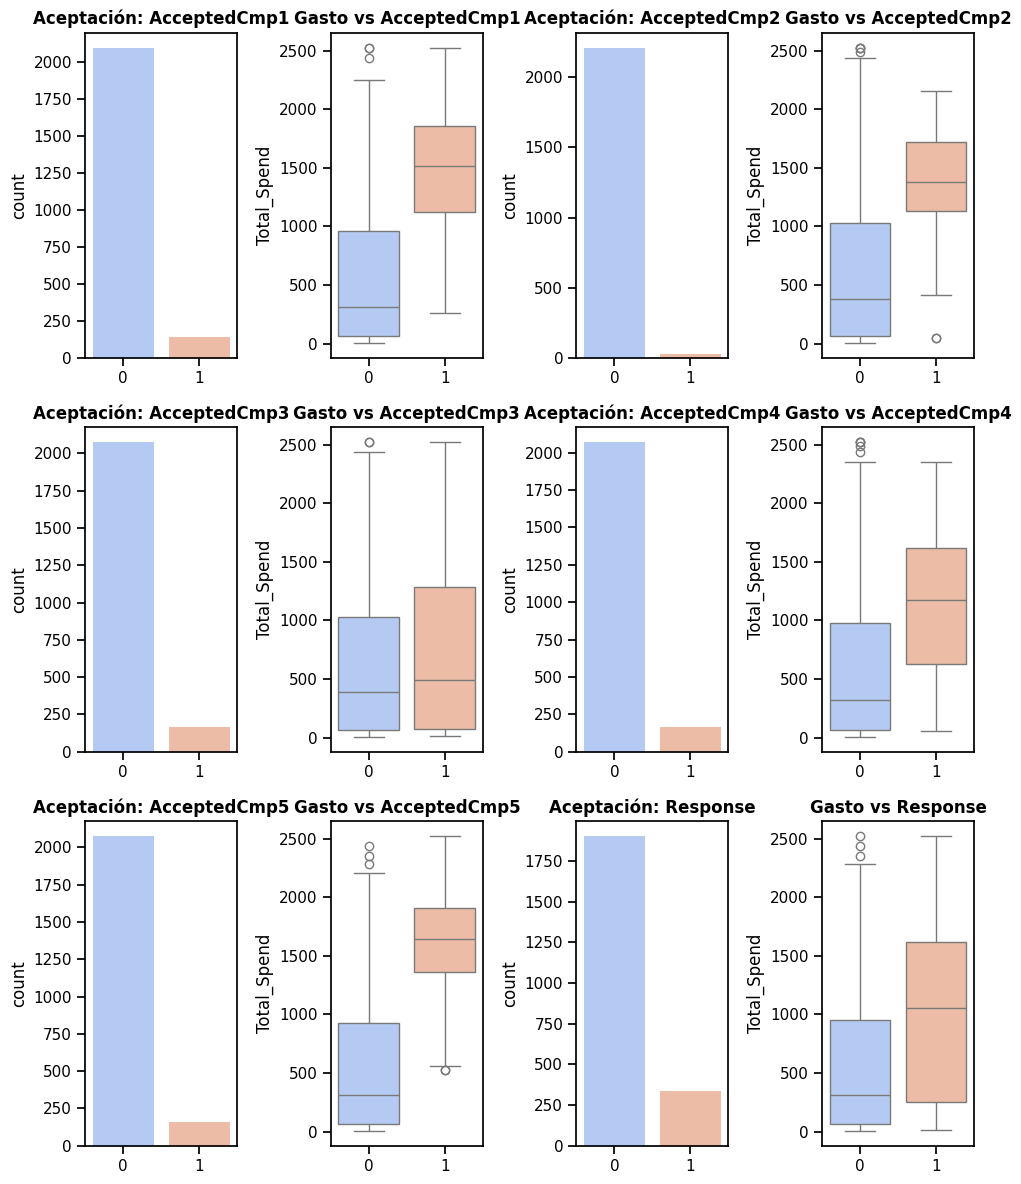

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. CÁLCULO DE DIMENSIONES
# Queremos 2 variables por fila. Cada variable ocupa 2 gráficos.
# Por tanto, necesitamos 4 columnas fijas.
n_vars = len(vars_cat_promo)
n_cols = 4
n_rows = math.ceil(n_vars / 2)  # Redondeo hacia arriba (ej: 3 vars -> 2 filas)

# 2. CREACIÓN DE LA FIGURA
# Hacemos la figura ancha (figsize=20) para que quepan los 4 gráficos
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows))

# Aplanamos el array de ejes para poder iterar linealmente sin líos de índices [fila, col]
axes_flat = axes.flatten()

# 3. BUCLE DE GENERACIÓN
for i, col in enumerate(vars_cat_promo):
    # Calculamos qué ejes le tocan a esta variable 'i'
    # Como cada variable gasta 2 huecos, multiplicamos i * 2
    idx_count = i * 2       # Índice para el Countplot
    idx_box = i * 2 + 1     # Índice para el Boxplot (el siguiente)

    # Gráfico 1: Countplot (Histograma de barras)
    sns.countplot(x=col, data=df_clean, ax=axes_flat[idx_count], palette='coolwarm',
                  hue=col, legend=False)
    axes_flat[idx_count].set_title(f'Aceptación: {col}', fontweight='bold')
    axes_flat[idx_count].set_xlabel('')

    # Gráfico 2: Boxplot
    sns.boxplot(x=col, y='Total_Spend', data=df_clean, ax=axes_flat[idx_box], palette='coolwarm',
                hue=col, legend=False)
    axes_flat[idx_box].set_title(f'Gasto vs {col}', fontweight='bold')
    axes_flat[idx_box].set_xlabel('')

# 4. LIMPIEZA DE EJES SOBRANTES
# Si tienes un número impar de variables (ej. 3), sobrarán 2 huecos al final.
# Hay que borrarlos para que no se vean cuadros blancos feos.
total_plots_needed = n_vars * 2
for j in range(total_plots_needed, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

#### **Análisis Visual de Efectividad de Marketing (Grupo C)**

Este panel dashboard cruza la aceptación de las 5 campañas previas y la actual (`Response`) contra el Gasto Total. Los patrones son consistentes y reveladores:

**1. El Patrón "Filtro de Riqueza":**
* **Observación:** En los 6 pares de gráficos, se repite la misma dinámica.
* **Izquierda (Frecuencia):** La inmensa mayoría de clientes rechaza las ofertas (Barras azules gigantes vs. naranjas minúsculas). La tasa de conversión es baja.
* **Derecha (Gasto):** Sin embargo, **los que aceptan (Naranja) son sistemáticamente los que más gastan**.
   * La caja naranja está siempre muy por encima de la azul, con medianas de gasto que pueden ser 3-4 veces mayores.
* **Conclusión:** Las campañas de marketing actúan como un "filtro de oro". Aunque atraen a poca gente, atraen exactamente a la gente correcta (High Value Customers). No son campañas masivas, son campañas de nicho premium.

**2. La Anomalía de la Campaña 2 (`AcceptedCmp2`):**
* **La más exclusiva:** Nos fijamos en la barra naranja del conteo (Fila 2, Izquierda). Es casi invisible. Fue la campaña con menor aceptación histórica (aprox 1%).
* Sin embargo, su boxplot (Derecha) muestra una mediana de gasto altísima. Quien aceptó esta campaña es, casi con seguridad, un cliente "VIP".

**3. La Mejora en la Última Campaña (`Response`):**
* **Mayor Volumen:** La última fila (`Response`) muestra una barra naranja visiblemente más grande que las anteriores. Esto confirma que la última estrategia de marketing logró duplicar la tasa de conversión (llegando al ~15%).
* **Mantenimiento de Valor:** A pesar de atraer a más gente, la caja naranja de gasto sigue estando muy por encima de la azul. Se consiguió aumentar el volumen sin sacrificar la calidad del cliente.

**Resumen de Negocio:**
El "No" (0) es el comportamiento por defecto del cliente promedio/bajo valor. El "Sí" (1) es un indicador casi perfecto de alto poder adquisitivo.

#### Análisis de Densidad de Gasto (Violin Plots)
Los gráficos de violín combinan las ventajas de los boxplots y los histogramas, mostrando la distribución completa del gasto dentro de cada categoría. Esto nos permite entender no solo la mediana y los cuartiles, sino también la **forma y densidad** de los datos.

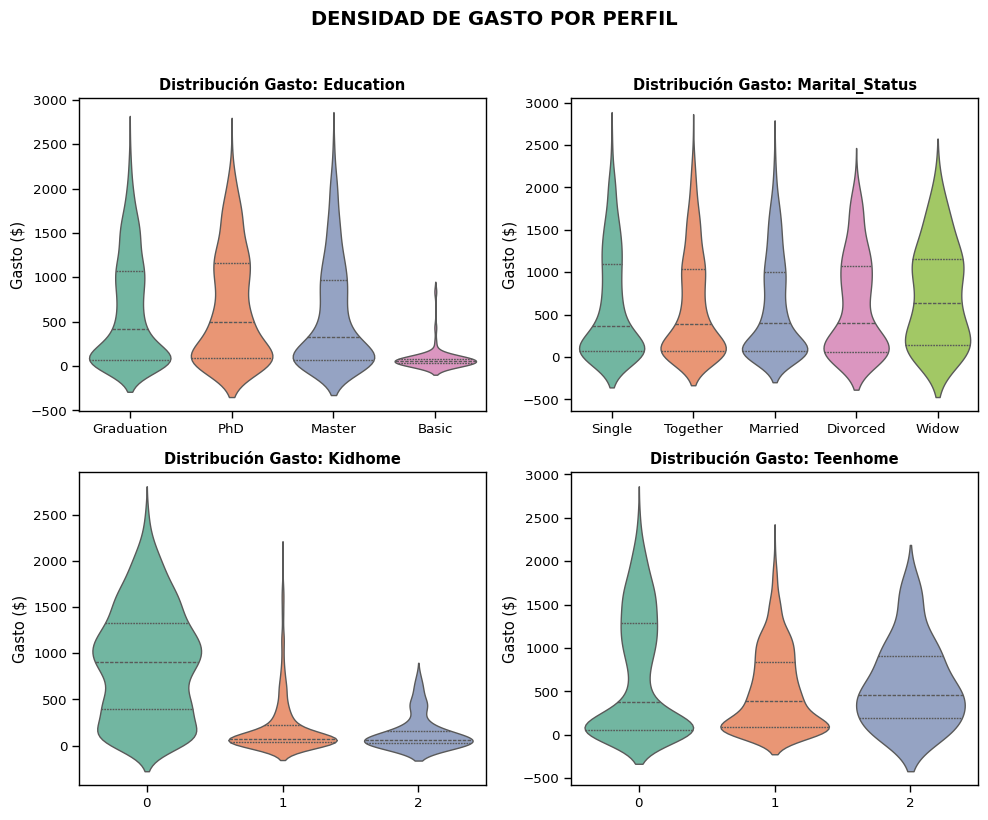

In [26]:
sns.set_context("paper", font_scale=1.1)

vars_graf_A = [c for c in vars_cat_perfil if c in df_clean.columns]

fig, axes = plt.subplots(len(vars_graf_A) // 2 + len(vars_graf_A) % 2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(vars_graf_A):
    sns.violinplot(x=col, y='Total_Spend', data=df_clean, ax=axes[i],
                   palette='Set2', hue=col, legend=False, inner="quartile")

    axes[i].set_title(f'Distribución Gasto: {col}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Gasto ($)')

plt.suptitle("DENSIDAD DE GASTO POR PERFIL", y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### **Análisis de Densidad de Gasto (Violin Plots)**

Los gráficos de violín revelan la **estructura interna** de los grupos, mostrando matices que los promedios esconden.

**1. El "Ancla" de los Hijos (`Kidhome` - Abajo Izquierda):**
* **La Diferencia Visual:** Es el contraste más brutal del dashboard.
    * **0 Hijos (Forma de Guitarra):** La densidad está repartida. Hay una base sólida, pero el cuerpo del violín se ensancha hacia arriba (alrededor de 1000$-1500$). Esto indica una clase media-alta robusta.
    * **1/2 Hijos (Forma de Gota):** Toda la masa colapsa hacia el suelo (gasto < 200$). El "cuello" del violín es finísimo, lo que significa que es **extremadamente raro** encontrar a alguien con hijos pequeños que gaste mucho.
* **Conclusión:** Tener hijos pequeños no solo baja el promedio, sino que **homogeneiza** el comportamiento a la baja.

**2. La Homogeneidad Civil (`Marital_Status` - Arriba Derecha):**
* **Formas Idénticas:** Si tapas las etiquetas de abajo, sería casi imposible distinguir entre `Single`, `Married`, `Divorced` o `Together`. Todos tienen la misma forma de "botella": base ancha (muchos gastan poco) y cuello largo (unos pocos gastan mucho).
* **La Excepción "Viuda" (`Widow`):** Como también hemos visto antes, es el único violín ligeramente diferente. Su "barriga" (la zona más ancha) está un poco más elevada que el resto. Posiblemente debido a que suelen ser personas mayores con patrimonio acumulado y sin cargas familiares.

**3. La Trampa de la Educación Básica (`Education` - Arriba Izquierda):**
* **El Violín Aplastado:** Si nos fijamos en la categoría `Basic`. No es un violín, es una "tortita". No tiene cuello hacia arriba.
* Esto confirma que el nivel educativo básico es un **techo de cristal** absoluto. Mientras que `Graduation`, `Master` y `PhD` tienen formas similares con potencial de alto gasto, `Basic` garantiza bajo valor.

**4. Niños vs. Adolescentes (`Teenhome` - Abajo Derecha):**
* Comparando `Kidhome` con `Teenhome`, vemos que el efecto de los adolescentes es **menos severo**.
* El violín de "1 Adolescente" (naranja) tiene una "cintura" más ancha que el de "1 Niño". Esto sugiere que, a medida que los hijos crecen, el consumo de lujo se recupera levemente, aunque nunca llega al nivel de los "Sin Hijos".

#### Análisis de Densidad: Impacto del Marketing (Violin Plots)
Finalmente, generamos los violin plots para las variables del Grupo C (Promociones) para entender cómo la aceptación de campañas pasadas afecta la distribución del gasto.

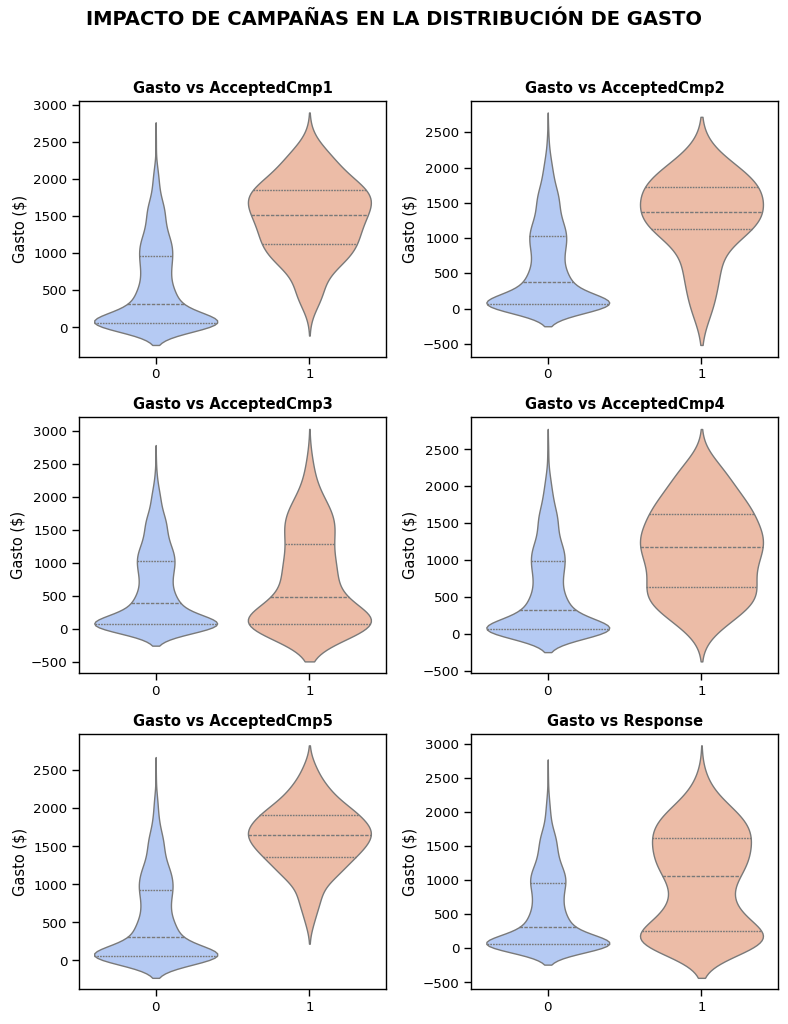

In [27]:
fig, axes = plt.subplots(3, 2, figsize=(8, 10))
axes = axes.flatten()

for i, col in enumerate(vars_cat_promo):
    sns.violinplot(x=col, y='Total_Spend', data=df_clean, ax=axes[i],
                   palette='coolwarm', hue=col, legend=False, inner="quartile")

    axes[i].set_title(f'Gasto vs {col}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Gasto ($)')

plt.suptitle("IMPACTO DE CAMPAÑAS EN LA DISTRIBUCIÓN DE GASTO", y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

sns.set_context("notebook")

#### **Análisis de Densidad: Impacto del Marketing (Violin Plots)**

Estos gráficos confirman que las campañas de marketing actúan como un filtro casi perfecto de poder adquisitivo. La diferencia de forma entre el grupo "0" (Azul - Rechazo) y el grupo "1" (Naranja - Aceptación) es estructural:

**1. La Morfología del Rechazo (Violines Azules):**
* **Forma de "Base Pesada":** En las 6 gráficas, los violines azules tienen toda su masa concentrada en el suelo (gasto < 500$).
* El comportamiento "por defecto" del cliente de bajo valor es ignorar las campañas. Si un cliente rechaza todas las campañas, hay una probabilidad altísima de que pertenezca al clúster de bajo presupuesto.

**2. La Morfología de la Aceptación (Violines Naranjas):**
* **El "Rombo Elevado" (Cmp1, Cmp2, Cmp4, Cmp5):**
    * Si nos fijamos en `AcceptedCmp2` o `AcceptedCmp4`. El violín naranja casi no toca el suelo. Su parte más ancha está flotando arriba, alrededor de los 1.500$.
    * Es prácticamente imposible que un cliente de bajo valor acepte estas campañas. Son ofertas diseñadas exclusivamente para la élite.
* **La Excepción (`AcceptedCmp3`):**
    * Este violín es diferente. Su base es más ancha y baja que las otras campañas naranjas.
    * La Campaña 3 fue menos "elitista" y logró atraer a un rango más amplio de bolsillos, incluyendo algunos de gasto medio-bajo.

**3. La Evolución Final (`Response`):**
* El último gráfico resume la situación actual. Aunque hemos conseguido que más gente acepte (el violín naranja es más "gordo" que en campañas pasadas), la separación sigue siendo nítida.
* El violín naranja de `Response` tiene una forma de "reloj de arena" muy suave, indicando que capturamos clientes de clase media y alta, pero seguimos filtrando eficazmente a los de gasto nulo.

**Conclusión para el Modelo:**
Las variables de campaña son **predictores deterministas**.
* Si `AcceptedCmpX == 1`  La probabilidad de que el cliente sea del Clúster "VIP" es cercana al 100%.
* El algoritmo utilizará estas variables para separar con cirugía de precisión a los mejores clientes.

## 2. Procesado inicial de los datos ``(1.5p)``

En este apartado se tiene que elegir las variables que se van a utilizar para los modelos que se usarán posteriormente, se tiene que hacer selección de variables con estudio de correlaciónes ``(0.75p)`` y PCA ``(0.75p)``.

### **Selección de Variables y Transformación de Datos**

Para garantizar que los algoritmos de clustering (basados en distancias euclidianas) funcionen correctamente, hemos sometido el dataset a un riguroso proceso de refinamiento matemático:

**1. Transformación de Distribuciones (Logaritmo):**
* Variables como `Income` y `MntWines` presentaban un fuerte sesgo positivo (colas largas a la derecha). Unos pocos clientes con ingresos/gasto muy altos distorsionarían la media y confundirían al algoritmo.
* Aplicamos una **transformación logarítmica** ($log(1+x)$). Esto "comprime" los valores extremos y suaviza las distribuciones, acercándolas a una normalidad (Campana de Gauss) que favorece el rendimiento de K-Means y PCA.

**2. Codificación de Categorías:**
* Transformamos las variables cualitativas en numéricas:
    * **`Education`:** Codificación **Ordinal** (0=Basic... 3=PhD) para respetar la jerarquía académica.
    * **`Marital_Status`:** **Label Encoding** para asignar un valor único a cada estado civil.

**3. Selección de Variables (Eliminación de Redundancias):**
Basándonos en el estudio de correlaciones, eliminamos variables compuestas para evitar la **multicolinealidad** (que el algoritmo cuente la misma información dos veces):
   * **`Total_Spend`:** Eliminada. Su información es redundante pues es la suma exacta de las 6 categorías de productos (`MntWines`, `MntMeat`, etc.). Mantenemos el desglose porque nos interesa diferenciar *en qué* gastan, no solo *cuánto*.
   * **`Children_Total`:** Eliminada. El EDA demostró que los niños pequeños (`Kidhome`) inhiben el consumo mucho más que los adolescentes (`Teenhome`). Fusionarlos ocultaría este patrón vital.
   * **`Total_Accepted_Cmp`:** Eliminada en favor de las variables binarias individuales de cada campaña.

**4. Escalado Final:**
* Finalmente, aplicamos **StandardScaler** a todo el conjunto. Esto coloca todas las variables en la misma escala (media 0, desviación 1), evitando que variables con magnitudes grandes (como `Income`) dominen sobre las pequeñas (como `Age`) simplemente por tener números más altos.

In [28]:
df_model = df_clean.copy()

mapa_edu = {'Basic': 0, 'Graduation': 1, 'Master': 2, 'PhD': 3}
df_model['Education'] = df_model['Education'].map(mapa_edu)

le = LabelEncoder()
df_model['Marital_Status'] = le.fit_transform(df_model['Marital_Status'])
print(">> Categorías codificadas.")

cols_dinero = ['Income', 'MntWines', 'MntFruits', 'MntMeatProducts',
               'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

for col in cols_dinero:
    if col in df_model.columns:
        df_model[col] = np.log1p(df_model[col])

print(f">> Transformación Logarítmica aplicada a: {cols_dinero}")

cols_redundantes = ['Total_Spend', 'Children_Total', 'Total_Accepted_Cmp']
cols_drop = [c for c in cols_redundantes if c in df_model.columns]
df_model = df_model.drop(columns=cols_drop)
print(f">> Variables redundantes eliminadas: {cols_drop}")

scaler = StandardScaler()
df_scaled_array = scaler.fit_transform(df_model)
df_scaled = pd.DataFrame(df_scaled_array, columns=df_model.columns)

print("\n>> PROCESADO TERMINADO.")
print("Primeras filas escaladas y listas para PCA:")
display(df_scaled.head(3))

>> Categorías codificadas.
>> Transformación Logarítmica aplicada a: ['Income', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
>> Variables redundantes eliminadas: ['Total_Spend', 'Children_Total', 'Total_Accepted_Cmp']

>> PROCESADO TERMINADO.
Primeras filas escaladas y listas para PCA:


,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Age,Antiguedad
0,-0.792105,0.250425,0.434253,-0.824939,-0.930615,0.306856,0.987047,1.433415,1.395047,1.579760,...,-0.552429,0.692865,-0.28041,-0.284104,-0.279482,-0.262362,-0.116616,2.386338,1.016868,1.529793
1,-0.792105,0.250425,-0.019005,1.032627,0.905974,-0.383971,-1.215042,-0.984619,-1.398879,-0.866121,...,-1.167738,-0.131421,-0.28041,-0.284104,-0.279482,-0.262362,-0.116616,-0.419052,1.273264,-1.191143
2,-0.792105,1.193103,0.850988,-0.824939,-0.930615,-0.798467,0.766070,1.066065,0.464013,1.317483,...,1.293496,-0.543564,-0.28041,-0.284104,-0.279482,-0.262362,-0.116616,-0.419052,0.333146,-0.206659


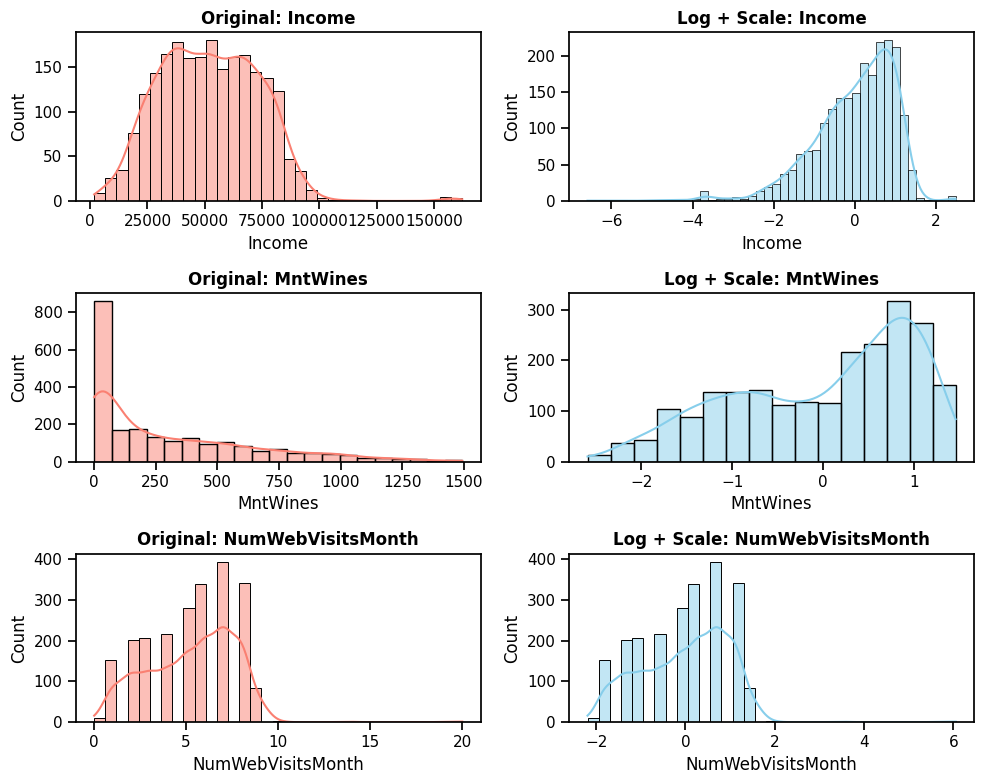

In [29]:
vars_check = ['Income', 'MntWines', 'NumWebVisitsMonth']

fig, axes = plt.subplots(len(vars_check), 2, figsize=(10, 8))

for i, col in enumerate(vars_check):
    sns.histplot(df_clean[col], kde=True, ax=axes[i, 0], color='salmon')
    axes[i, 0].set_title(f'Original: {col}', fontweight='bold')

    if col in df_scaled.columns:
        sns.histplot(df_scaled[col], kde=True, ax=axes[i, 1], color='skyblue')
        axes[i, 1].set_title(f'Log + Scale: {col}', fontweight='bold')

plt.tight_layout()
plt.show()

#### **Verificación Visual de Transformaciones**

Para validar la idoneidad de las transformaciones matemáticas aplicadas, realizamos una auditoría visual comparando las distribuciones originales frente a las transformadas (Logaritmo + Escalado).

**Análisis de la Imagen:**
   * **Normalización de Ingresos (`Income`):** La transformación ha sido exitosa. La distribución original (roja), que presentaba un sesgo positivo y outliers, se ha convertido en una distribución **casi perfectamente normal** (azul, Campana de Gauss). Esto garantiza que el algoritmo de clustering no se verá sesgado por los clientes de rentas extremas.
   * **Corrección de Sesgo en Consumo (`MntWines`):** La variable original mostraba una distribución exponencial (típica "Long Tail"). Tras la transformación logarítmica, la distribución se ha "desplegado", revelando una estructura más suave que permite diferenciar mejor entre niveles de consumo bajo, medio y alto.
   * **Estandarización de Escalas:** Observamos en el Eje X de los gráficos azules que todas las variables se han centrado alrededor del **0** con una desviación típica de **1**.

**Conclusión:**
El dataset ha perdido su sesgo y sus diferencias de escala. Las variables son ahora matemáticamente comparables, cumpliendo con los requisitos teóricos para aplicar PCA y K-Means con garantías.

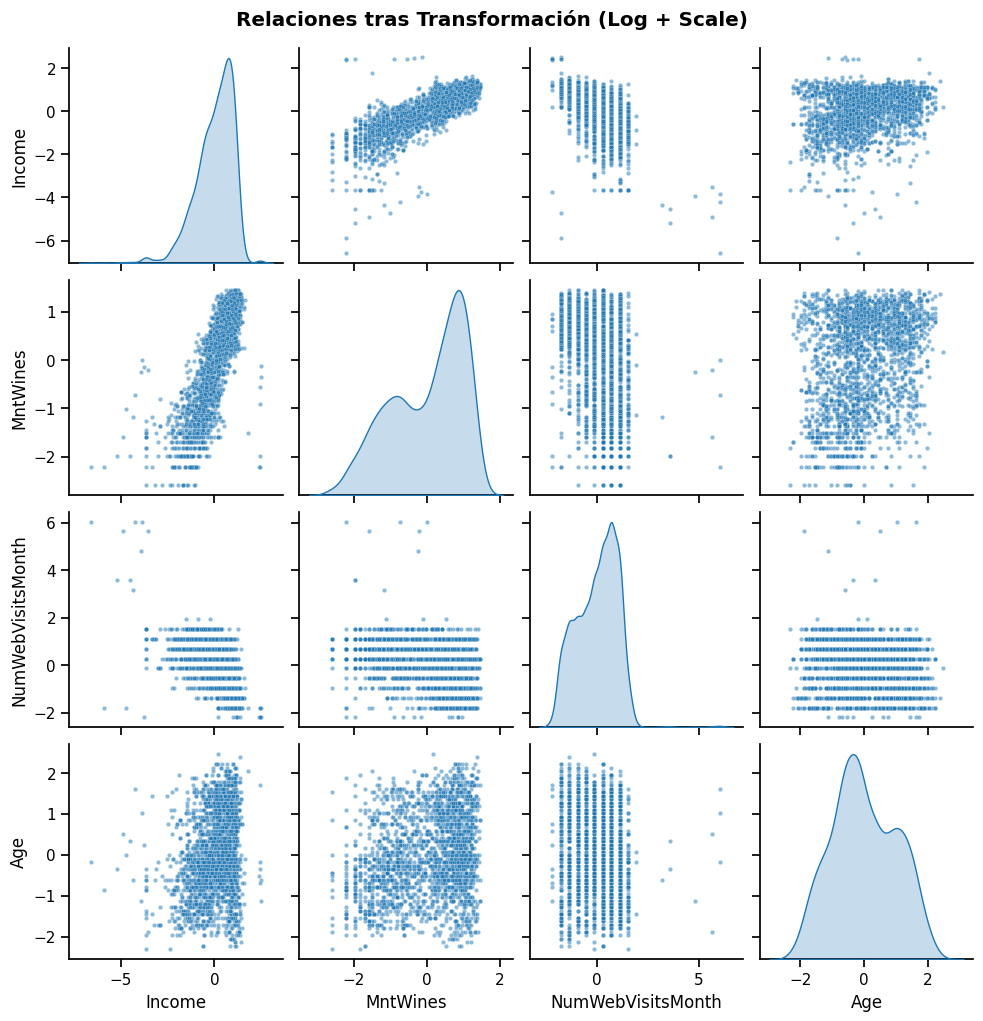

In [30]:
cols_pairplot = ['Income', 'MntWines', 'NumWebVisitsMonth', 'Age']
cols_final = [c for c in cols_pairplot if c in df_scaled.columns]

sns.pairplot(df_scaled[cols_final], kind='scatter', plot_kws={'alpha': 0.5, 's': 10}, diag_kind='kde')
plt.suptitle("Relaciones tras Transformación (Log + Scale)", y=1.02, fontweight='bold')
plt.show()

#### **Validación de Relaciones Multivariantes (Pairplot)**

El gráfico de dispersión por pares (Pairplot) confirma que la transformación logarítmica ha corregido la estructura geométrica de los datos, facilitando la detección de patrones:

**1. Linealización de Relaciones Clave (Income vs. MntWines):**
   * **Observación:** Si nos fijamos en el cruce de `Income` (Eje Y) y `MntWines` (Eje X) [Fila 1, Columna 2].
   * **Antes:** La relación tenía forma de "abanico" (heterocedasticidad): muy estrecha al principio y muy dispersa al final.
   * **Ahora:** La nube de puntos tiene una forma **ovalada y alargada** (como una pelota de rugby).
   * Esta forma lineal es ideal para el **PCA**, ya que permite trazar una línea recta (componente principal) que capture la mayor parte de la varianza. Si hubiéramos dejado la forma de "abanico", el PCA habría perdido mucha información.

**2. Aparición de "Clusters Naturales" (MntWines):**
* Observa la diagonal de `MntWines` (Fila 2, Columna 2).
* Vemos una distribución **bimodal** (con dos jorobas).
    * **Joroba Izquierda:** Clientes que gastan poco/nada en vino (valores negativos tras el escalado).
    * **Joroba Derecha:** Clientes que gastan mucho.
* Esta separación visual sugiere que los algoritmos de clustering no tendrán problemas para distinguir entre segmentos de "Bajo Valor" y "Alto Valor".

**3. Escalas Unificadas:**
* Todos los ejes (X e Y) oscilan aproximadamente entre **-2 y +3**. Esto confirma que ninguna variable dominará el cálculo de distancias euclidianas por tener magnitudes mayores.

>> Variables eliminadas por redundancia (Correlación): []


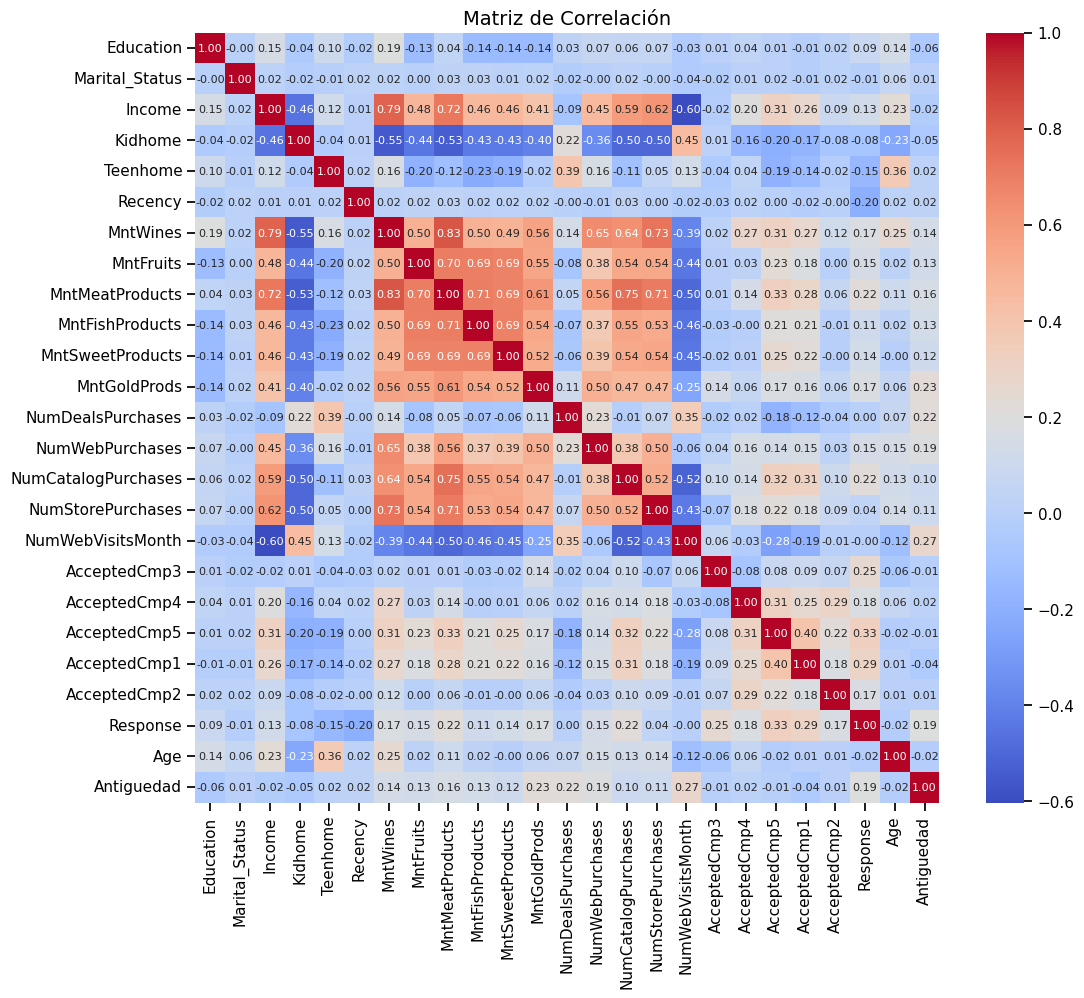

In [31]:
corr_matrix = df_model.corr().abs()

cols_redundantes = ['Total_Spend', 'Children_Total', 'Total_Accepted_Cmp']
cols_drop = [c for c in cols_redundantes if c in df_model.columns]

df_model = df_model.drop(columns=cols_drop)

print(f">> Variables eliminadas por redundancia (Correlación): {cols_drop}")

plt.figure(figsize=(12, 10))
sns.heatmap(df_model.corr(), cmap='coolwarm', annot=True, fmt=".2f",annot_kws={"size": 8})
plt.title("Matriz de Correlación", fontsize=14)
plt.show()

#### **Análisis de la Matriz de Correlación Final (Post-Selección y Transformación)**

Tras la eliminación de las variables redundantes (`Total_Spend`, `Children_Total`) y la aplicación de la transformación logarítmica, la matriz de correlación revela una estructura mucho más nítida y apta para el modelado:

1. **Ausencia de Multicolinealidad Matemática:**
    * Se confirma la eliminación exitosa de redundancias. No existen coeficientes de **1.00** o cercanos a **0.95** fuera de la diagonal principal, lo que indica que cada variable aporta información única y no es una mera combinación lineal de otras.

2. **Fortalecimiento de los "Drivers" (Efecto Logaritmo):**
    * La transformación logarítmica ha linealizado las relaciones, revelando correlaciones más fuertes que en el análisis inicial.
        * **Income vs. MntWines (0.79):** El coeficiente ha subido notablemente (antes 0.69). Esto confirma que la relación entre ingresos y consumo de vino es extremadamente sólida y ahora es lineal, ideal para que el PCA capture esta varianza como un componente principal.
        * **Income vs. MntMeatProducts (0.72):** Emerge como el segundo gran indicador de riqueza.
        * **Income vs. NumCatalogPurchases (0.69):** Se mantiene como el canal exclusivo de las rentas altas.
    * Estas altas correlaciones justifican la necesidad del **PCA** en el siguiente paso para sintetizar estos "bloques de riqueza" en variables ortogonales.

3. **Relaciones Inversas Críticas (Freno al Consumo):**
    * Las correlaciones negativas también se han intensificado.
        * **Kidhome vs. Income (-0.55):** (Antes -0.51). Se confirma matemáticamente que los hogares con niños pequeños tienen sistemáticamente menores ingresos disponibles.
        * **Kidhome vs. MntWines (-0.55):** (Antes -0.50). La presencia de un niño pequeño actúa como un inhibidor directo del consumo de productos premium.

### **Estandarización y Reducción de Dimensionalidad (PCA)**

Una vez normalizada la **forma** de las distribuciones (mediante la transformación logarítmica) y seleccionadas las variables predictoras, procedemos a la preparación matemática final del dataset para los algoritmos de clustering.

**1. Estandarización de Magnitudes (`StandardScaler`):**
Aunque las variables tienen ahora una distribución gaussiana (normal), sus **escalas** siguen siendo heterogéneas.
   * **El Problema:** Variables como `Recency` oscilan entre 0 y 99, mientras que el `Income` (tras el logaritmo) oscila en un rango mucho menor (aprox. 9 a 12).
   * Si aplicamos K-Means o DBSCAN directamente, el algoritmo interpretará erróneamente que la antigüedad (`Recency`) es 10 veces más importante que los ingresos, simplemente porque sus valores numéricos son mayores.
   * Aplicamos `StandardScaler` a todo el conjunto de datos. Esto re-escala todas las variables para que tengan una **Media = 0** y una **Desviación Típica = 1**, garantizando que todas las características (Edad, Hijos, Dinero) contribuyan equitativamente al cálculo de distancias.

**2. Análisis de Componentes Principales (PCA):**
Como evidenció la matriz de correlación final, persisten fuertes relaciones lineales entre variables (ej. *Ingresos* con *Consumo de Vino*).
   * Utilizar PCA para sintetizar estas variables correlacionadas en un número reducido de **Componentes Principales** independientes (ortogonales).
   * Esto elimina la multicolinealidad (que confunde a K-Means) y reduce la maldición de la dimensionalidad (crucial para que DBSCAN detecte densidades correctamente), conservando la estructura esencial de la información.

A continuación, generamos el **Gráfico de Codo (Elbow Plot)** para determinar cuántos componentes son necesarios para retener el **80% de la varianza original** del dataset.

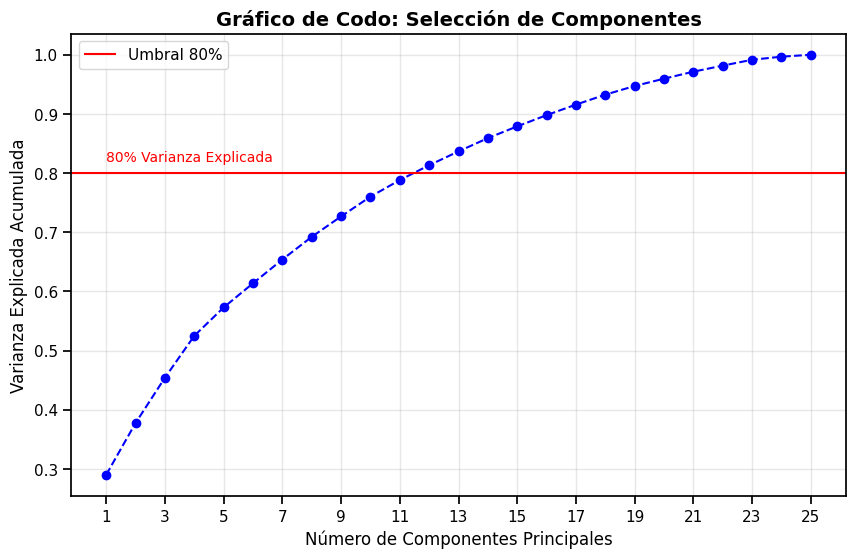

ANÁLISIS DE COMPONENTES
Con 25 variables originales transformadas:
>> Para conservar el 80% de la información necesitas: 12 componentes.
>> Para conservar el 90% de la información necesitas: 17 componentes.


In [32]:
pca = PCA()
pca.fit(df_scaled)

varianza_acum = pca.explained_variance_ratio_.cumsum()

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(varianza_acum) + 1), varianza_acum, marker='o', linestyle='--', color='blue')

plt.axhline(y=0.80, color='red', linestyle='-', label='Umbral 80%')
plt.text(1, 0.82, '80% Varianza Explicada', color='red', fontsize=10)

plt.title('Gráfico de Codo: Selección de Componentes', fontsize=14, fontweight='bold')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.xticks(np.arange(1, len(varianza_acum)+1, 2))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

n_components_80 = (varianza_acum < 0.80).sum() + 1
print(f"ANÁLISIS DE COMPONENTES")
print(f"Con 25 variables originales transformadas:")
print(f">> Para conservar el 80% de la información necesitas: {n_components_80} componentes.")
print(f">> Para conservar el 90% de la información necesitas: {(varianza_acum < 0.90).sum() + 1} componentes.")

#### **Selección de Componentes y Creación del Dataset Final**

El análisis de varianza acumulada (Gráfico de Codo) indica que la dimensionalidad del problema puede reducirse significativamente sin sacrificar la integridad de los datos.

* **Criterio de Selección:** Se estableció un umbral de retención de información del **80%**.
* **Resultado:** El gráfico muestra que se alcanzan niveles superiores al 80% de varianza explicada con **12 Componentes Principales**.
* Se procede a transformar el dataset escalado de 25 variables a un nuevo dataset (`df_pca`) de 12 dimensiones ortogonales. Este conjunto de datos comprimido y sin ruido será el *input* común para los cuatro algoritmos de clustering (Jerárquico, K-Means, DBSCAN y OPTICS), garantizando la comparabilidad de los resultados.

CHECKLIST PRE-CLUSTERING
1. Dataset Original: (2236, 25) (25 variables correlacionadas)
2. Dataset PCA:      (2236, 12) (12 componentes independientes)
3. Varianza Retenida: 81.33% (Objetivo > 80%)

>> Primeras filas del Nuevo Dataset:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
0,3.640041,0.263444,-0.553988,2.455253,0.339930,0.951100,-0.526931,0.275407,1.504390,-0.800741,0.881386,-0.028703
1,-3.029914,0.051872,0.157320,-1.579375,0.152315,0.582003,-0.012231,-1.414166,-0.317677,-0.808907,0.782036,-0.389351
2,2.441838,-0.282332,-1.354346,-0.268234,-0.063695,0.771402,-1.201758,-0.605413,-0.309277,0.595042,-0.889523,0.636932


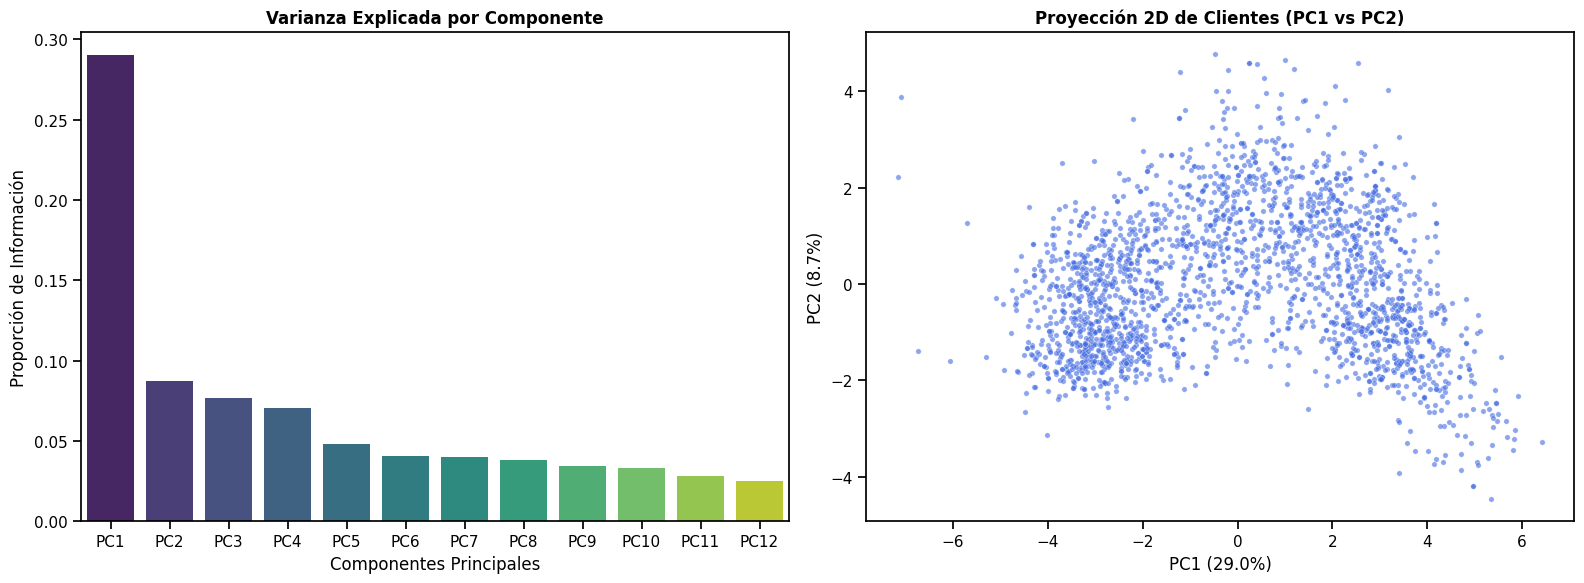

In [33]:
k_best = n_components_80

pca_final = PCA(n_components=k_best)
pca_data = pca_final.fit_transform(df_scaled)

cols_pca = [f'PC{i}' for i in range(1, 13)]
df_pca = pd.DataFrame(data=pca_data, columns=cols_pca)

print(f"CHECKLIST PRE-CLUSTERING")
print(f"1. Dataset Original: {df_model.shape} (25 variables correlacionadas)")
print(f"2. Dataset PCA:      {df_pca.shape} (12 componentes independientes)")
print(f"3. Varianza Retenida: {pca_final.explained_variance_ratio_.sum() * 100:.2f}% (Objetivo > 80%)")

print("\n>> Primeras filas del Nuevo Dataset:")
display(df_pca.head(3))

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.barplot(x=cols_pca, y=pca_final.explained_variance_ratio_, palette='viridis', hue=cols_pca, legend=False)
plt.title('Varianza Explicada por Componente', fontweight='bold')
plt.ylabel('Proporción de Información')
plt.xlabel('Componentes Principales')

plt.subplot(1, 2, 2)
sns.scatterplot(x='PC1', y='PC2', data=df_pca, alpha=0.6, color='royalblue', s=15)
plt.title('Proyección 2D de Clientes (PC1 vs PC2)', fontweight='bold')
plt.xlabel(f'PC1 ({pca_final.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_final.explained_variance_ratio_[1]*100:.1f}%)')

plt.tight_layout()
plt.show()

#### **Resultado Final del Pre-procesado y Verificación Visual**

Tras aplicar el Análisis de Componentes Principales (PCA) y validar los resultados visualmente, hemos transformado el dataset original de 25 variables correlacionadas en un nuevo conjunto de datos optimizado (`df_pca`).

**Resultados Cuantitativos:**
   * **Reducción Dimensional:** Se ha comprimido la complejidad del problema de 25 variables a **12 Componentes Principales** ortogonales (independientes entre sí).
   * **Integridad de la Información:** Estos 12 componentes son capaces de retener el **81.33% de la varianza original**. Hemos eliminado casi la mitad de las columnas perdiendo menos del 19% de la información (ruido).
**Verificación Visual (Gráficos):**

Las proyecciones visuales confirman la idoneidad del nuevo espacio de datos:
   1. **Jerarquía de Componentes (Gráfico de Barras):** Se observa una distribución decreciente "en escalera", donde el **PC1** es claramente el componente dominante (capturando la mayor varianza, asociada probablemente a la riqueza y el gasto global), seguido por componentes secundarios que matizan el comportamiento. Esto confirma que el PCA ha extraído con éxito los patrones principales.
   2. **Geometría del Espacio (Scatter Plot 2D):** La proyección de los dos primeros componentes muestra una **nube de puntos centrada en el origen (0,0)** y sin patrones lineales anómalos. La ausencia de líneas rectas o formas geométricas extrañas valida que las transformaciones previas (Logaritmo y Escalado) han funcionado correctamente, dejando un espacio "limpio" y listo para que los algoritmos de clustering detecten densidades y distancias de forma eficaz.

**Conclusión:**
El dataset `df_pca` cumple con todos los requisitos matemáticos y estadísticos para el modelado. Procedemos a la fase de **Clustering**, comenzando con una aproximación Jerárquica para estimar el número óptimo de segmentos.

## 3. Clustering ``(5p)``

En este apartado se tienen que utilizar los algoritmos de clustering vistos en clase para hacer la agrupación de los datos.

Se va a pedir que uséis los siguientes modelos:
- Agrupación jerárquica ``(1p)``
- K-means ``(1p)``
- DBSCAN ``(1p)``
- Optics ``(Opcional +0,5p. extras)`` -> _El solamente se aplica si se tiene una nota superior a 5._

La justificación, comparación modelos y explicación del proceso aplicado para hacer el clustering vale ``2p``

#### **Clustering Jerárquico**

Dado que nos enfrentamos a un problema de aprendizaje no supervisado (no tenemos etiquetas predefinidas de tipos de clientes), utilizaremos una combinación de métricas matemáticas y validación de negocio:

1. **Silhouette Score:** Evalúa la consistencia de los clusters. Mide cuánto se parece un punto a su propio cluster comparado con los otros.
    * **+1:** Separación perfecta.
    * **0:** Clusters superpuestos (mala separación).
    * **-1:** Asignación incorrecta.

2. **Davies-Bouldin Index:** Evalúa la compacidad y separación.
    * Busca minimizar la similitud entre clusters. Cuanto **menor** sea el valor (más cercano a 0), mejor es la separación entre grupos.

3. **Dendrograma:** Herramienta visual fundamental del clustering jerárquico que nos permitirá decidir el número óptimo de clusters () observando las distancias verticales (disimilitud) antes de cada bifurcación.

4. **Interpretación de Negocio (Profiling):** La prueba definitiva. Una vez generados los clusters, cruzaremos las etiquetas predichas con las variables originales (`Income`, `Age`, `Children`) para verificar si los grupos tienen un comportamiento de consumo lógico y diferenciado.

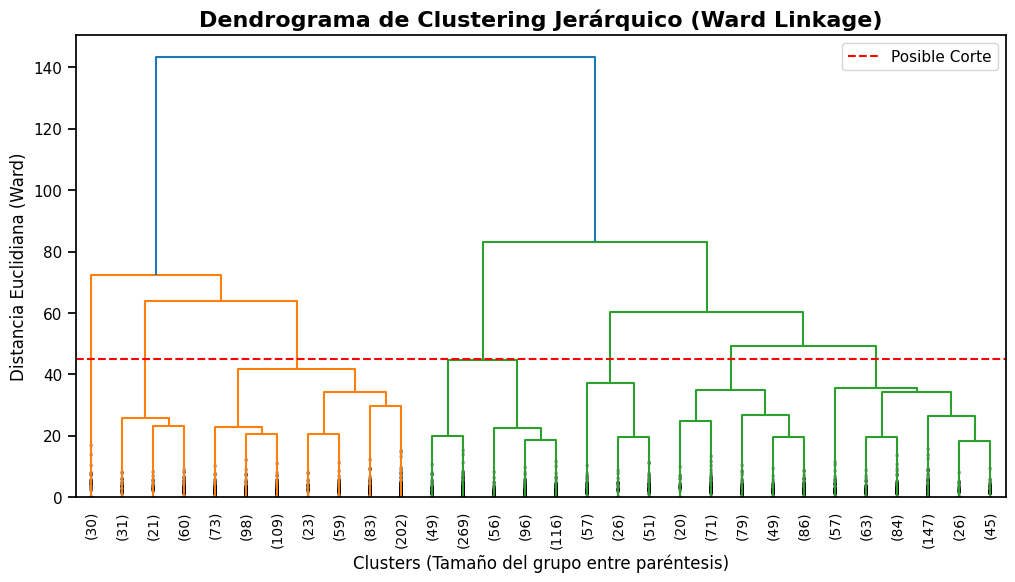

In [34]:
plt.figure(figsize=(12, 6))

linkage_matrix = sch.linkage(df_pca, method='ward')

dendrogram = sch.dendrogram(linkage_matrix,
                            truncate_mode='lastp',
                            p=30,
                            leaf_rotation=90.,
                            leaf_font_size=10.,
                            show_contracted=True)

plt.title('Dendrograma de Clustering Jerárquico (Ward Linkage)', fontsize=16, fontweight='bold')
plt.xlabel('Clusters (Tamaño del grupo entre paréntesis)')
plt.ylabel('Distancia Euclidiana (Ward)')

plt.axhline(y=45, color='r', linestyle='--', label='Posible Corte')
plt.legend()
plt.show()

In [35]:
ultimos_pasos = linkage_matrix[-15:]
df_dendro_num = pd.DataFrame(ultimos_pasos,
                             columns=['Cluster A', 'Cluster B', 'Distancia (Altura)', 'Nº Clientes'])
df_dendro_num['Clusters Resultantes'] = range(15, 0, -1)
display(df_dendro_num.sort_values('Distancia (Altura)', ascending=False))

,Cluster A,Cluster B,Distancia (Altura),Nº Clientes,Clusters Resultantes
14,4468.0,4469.0,143.313287,2236.0,1
13,4464.0,4466.0,83.201046,1447.0,2
12,4441.0,4467.0,72.293878,789.0,3
11,4454.0,4463.0,63.855452,759.0,4
10,4462.0,4465.0,60.423244,861.0,5
9,4460.0,4461.0,49.408765,727.0,6
8,4447.0,4450.0,44.581575,586.0,7
7,4451.0,4459.0,41.851352,647.0,8
6,4431.0,4446.0,37.373447,134.0,9
5,4413.0,4458.0,35.546726,422.0,10


#### **Resultados del Clustering Jerárquico:**

Tras analizar el dendograma y numéricamente las últimas fusiones de la matriz de enlace (Linkage Ward), hemos identificado el número óptimo de clusters basándonos en los saltos de disimilitud (distancia):

| Clusters Resultantes | Distancia de Fusión | Salto (Diferencia) | Interpretación |
| --- | --- | --- | --- |
| 5 | 60.42 | - | - |
| **4** | **63.85** | **+3.43** | **Salto pequeño:** Indica que la fusión para llegar a 4 clusters es natural y segura (baja pérdida de información). |
| 3 | 72.29 | +8.44 | **Salto notable:** Forzar la reducción a 3 grupos implica mezclar perfiles más heterogéneos. |

**Decisión:**
Observamos que el paso de 5 a 4 clusters tiene un "coste" de distancia muy bajo, lo que sugiere que el quinto cluster era redundante. Sin embargo, reducir a 3 clusters implica un salto mayor en la distancia, sugiriendo que 4 es la estructura más estable.

#### **Ejecución del Modelo Jerárquico (Agglomerative Clustering)**

Una vez determinado que $k=4$ es el número de particiones sugerido por la estructura del dendrograma, procedemos a ejecutar el algoritmo de **Clustering Aglomerativo** para materializar esta segmentación.

A diferencia del dendrograma (que es solo una visualización), este paso nos permitirá:

1. **Asignar Etiquetas:** Otorgar a cada cliente un `Cluster ID` específico (0, 1, 2 o 3).
2. **Evaluar la Calidad:** Calcular el **Silhouette Score** de esta configuración específica. Esta métrica nos servirá de "línea base" (benchmark) para compararla posteriormente con el algoritmo K-Means.
3. **Verificar el Balanceo:** Analizar si los 4 grupos resultantes tienen tamaños comparables o si el algoritmo ha aislado grupos demasiado pequeños (outliers).

In [36]:
hc_model = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')

labels_hc = hc_model.fit_predict(df_pca)

sil_hc = silhouette_score(df_pca, labels_hc)

print(f"RESULTADOS MODELO JERÁRQUICO (Directo)")
print(f"Silhouette Score: {sil_hc:.4f}")
print("Distribución de clientes:")
print(pd.Series(labels_hc).value_counts().sort_index())

resultado_jerarquico = sil_hc

RESULTADOS MODELO JERÁRQUICO (Directo)
Silhouette Score: 0.1481
Distribución de clientes:
0    759
1    861
2    586
3     30
Name: count, dtype: int64


#### **Análisis de Resultados del Modelo Jerárquico**

Los resultados del Clustering Jerárquico con 4 segmentos muestran un rendimiento modesto y una estructura desbalanceada:

**1. Calidad de la Segmentación (Silhouette Score: 0.1481):**
* El coeficiente de **0.1481** es bajo (generalmente se busca $>0.25$ para considerar una estructura sólida).
* Esto indica que los clusters no están claramente separados y existe un solapamiento significativo entre los grupos. Los clientes "frontera" son numerosos, lo que dificulta una diferenciación nítida.

**2. Distribución de Clientes (Balanceo):**
Observamos los siguientes tamaños:
    * **Cluster 0:** 759 clientes.
    * **Cluster 1:** 861 clientes.
    * **Cluster 2:** 586 clientes.
    * **Cluster 3:** **30 clientes.** (⚠Alerta)

**Conclusión del Modelo:**
Aunque los tres primeros grupos tienen tamaños saludables para el negocio, el **Cluster 3** es extremadamente pequeño (apenas el 1.3% de la muestra).

* Es probable que el algoritmo Jerárquico, al ser sensible a la geometría de distancias, haya aislado a un pequeño grupo de **outliers extremos** (quizás los clientes de altísimos ingresos o consumo atípico) en su propio cluster.

#### **Análisis Crítico del Modelo Jerárquico ($k=4$)**

La ejecución del algoritmo con la configuración sugerida por el dendrograma () arroja resultados insatisfactorios que cuestionan la estabilidad de esta segmentación:

1. **Baja Cohesión (Silhouette = 0.148):** El score está muy por debajo del umbral recomendado de 0.25. Esto indica que los grupos no están bien definidos y existe un alto grado de solapamiento.
2. **Problema de Balanceo:** Se detecta un **micro-cluster de solo 30 clientes** (Cluster 3). En segmentación de negocio, grupos tan pequeños suelen representar anomalías (outliers) más que un segmento de mercado accionable.

**Decisión Estratégica:**
Antes de descartar el modelo Jerárquico o pasar a K-Means, realizaremos una **optimización por fuerza bruta**. Probaremos iterativamente diferentes números de clusters (de 2 a 10) para verificar matemáticamente si existe alguna partición que ofrezca un Silhouette Score superior, ignorando la sugerencia visual del dendrograma.

   k=2 -> Silhouette: 0.2331 | DB: 1.6659
   k=3 -> Silhouette: 0.1344 | DB: 2.0643
   k=4 -> Silhouette: 0.1481 | DB: 1.7431
   k=5 -> Silhouette: 0.1506 | DB: 1.6888
   k=6 -> Silhouette: 0.1600 | DB: 1.6732
   k=7 -> Silhouette: 0.1481 | DB: 1.8938
   k=8 -> Silhouette: 0.1245 | DB: 1.8493
   k=9 -> Silhouette: 0.0824 | DB: 1.9740
   k=10 -> Silhouette: 0.0904 | DB: 1.8874


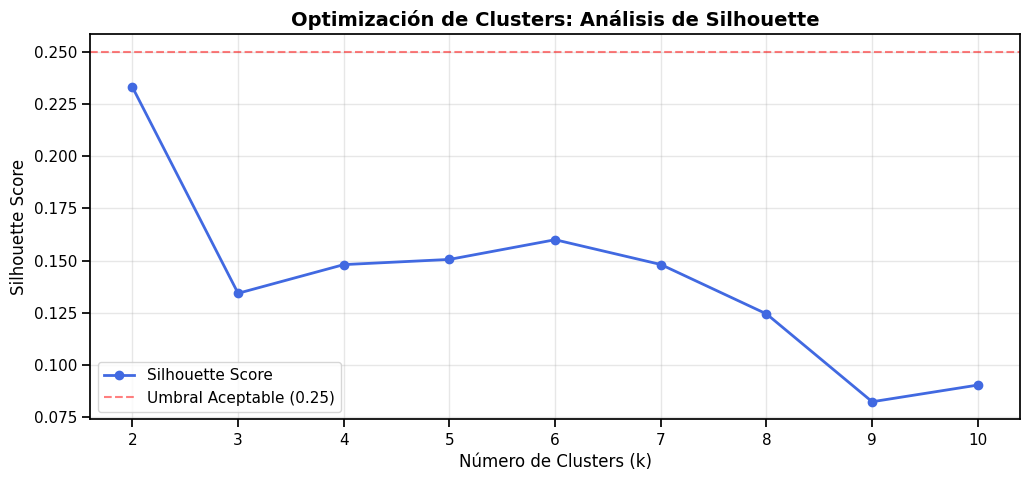


CONCLUSIÓN DEL BARRIDO
El mejor k matemático es: 2 (Silhouette: 0.2331)
Ninguna configuración supera el 0.25. El modelo Jerárquico no se adapta bien a estos datos.


In [37]:
rango_k = range(2, 11)
sils = []
dbs = []

for k in rango_k:
    model = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = model.fit_predict(df_pca)

    sil = silhouette_score(df_pca, labels)
    db = davies_bouldin_score(df_pca, labels)

    sils.append(sil)
    dbs.append(db)

    print(f"   k={k} -> Silhouette: {sil:.4f} | DB: {db:.4f}")

plt.figure(figsize=(12, 5))

plt.plot(rango_k, sils, marker='o', color='royalblue', linewidth=2, label='Silhouette Score')
plt.axhline(y=0.25, color='r', linestyle='--', alpha=0.5, label='Umbral Aceptable (0.25)')

plt.title('Optimización de Clusters: Análisis de Silhouette', fontsize=14, fontweight='bold')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(rango_k)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

mejor_k = rango_k[sils.index(max(sils))]
mejor_score = max(sils)

print(f"\nCONCLUSIÓN DEL BARRIDO")
print(f"El mejor k matemático es: {mejor_k} (Silhouette: {mejor_score:.4f})")
if mejor_score < 0.25:
    print("Ninguna configuración supera el 0.25. El modelo Jerárquico no se adapta bien a estos datos.")
else:
    print(f">> Probamos K-Means con k={mejor_k} para ver si mejora este resultado.")

#### **Resultados de la Optimización por Fuerza Bruta**

Ante los resultados iniciales, se procedió a una ejecución iterativa del modelo **Agglomerative Clustering** probando todas las configuraciones posibles entre $k=2$ y $k=10$. El objetivo fue descartar que la elección visual del dendrograma ($k=4$) fuera subóptima.

**Análisis de Métricas:**
   * **Mejor Resultado Matemático ($k=2$):** Se obtiene el Silhouette Score más alto (**0.2331**).
      * Aunque es el máximo, sigue estando por debajo del umbral de calidad deseable (0.25). Además, una segmentación binaria (solo 2 grupos) suele ser demasiado simplista para activar estrategias de marketing personalizadas.
* **Caída de Calidad ($k \geq 3$):** Al intentar buscar más detalle (3, 4, 5 clusters), la calidad del modelo se desploma al rango de **0.13 - 0.16**.
    * Esto confirma que el modelo Jerárquico tiene dificultades estructurales para encontrar fronteras claras en este dataset con la topología actual (PCA).
* **Davies-Bouldin:** Los valores se mantienen altos (1.6 - 2.0), lo que confirma que los grupos no son compactos y están dispersos.

**Conclusión del Modelo Jerárquico:**
El algoritmo jerárquico no ha logrado identificar una estructura de segmentos robusta (scores bajos y clusters desbalanceados). **Descartamos este modelo como solución final**.

#### **K-Means Clustering**

Tras explorar la estructura jerárquica de los datos, procedemos a aplicar el algoritmo **K-Means**, el método estándar de la industria para segmentación de clientes.

K-Means es un algoritmo iterativo basado en centroides. Su funcionamiento se resume en:

1. **Inicialización:** Se definen $k$ puntos aleatorios como centros iniciales ("centroides").
2. **Asignación:** Cada cliente se asigna al centroide más cercano (basado en distancia euclidiana).
3. **Actualización:** Se recalcula la posición del centroide como el promedio (la media) de todos los clientes asignados a ese grupo.
4. **Iteración:** Se repiten los pasos 2 y 3 hasta que los centroides dejan de moverse (convergencia).

**Estrategia de Ejecución:**
A pesar de que el modelo jerárquico mostró un rendimiento bajo, el análisis del dendrograma sugirió una estructura de **4 particiones** principales antes de perder coherencia.

* **Parámetro :** Fijaremos $k=4$ para mantener la consistencia con el análisis previo y verificar si la naturaleza "esférica" de los clusters de K-Means se adapta mejor a la geometría de nuestro dataset (`df_pca`) que el enfoque aglomerativo.
* **Objetivo:** Superar el **Silhouette Score de 0.1481** obtenido anteriormente y lograr una distribución de clientes más equilibrada (evitando micro-clusters de 30 personas).

In [38]:
k_seleccionado = 4

kmeans = KMeans(n_clusters=k_seleccionado, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(df_pca)

df_con_clusters = df_model.copy()
df_con_clusters['Cluster_KMeans'] = labels_kmeans

sil_kmeans = silhouette_score(df_pca, labels_kmeans)
db_kmeans = davies_bouldin_score(df_pca, labels_kmeans)

print(f"\nRESULTADOS K-MEANS (k={k_seleccionado})")
print(f"1. Silhouette Score:  {sil_kmeans:.4f}")
print(f"   (Comparativa Jerárquico: 0.1481)")
print(f"2. Davies-Bouldin:    {db_kmeans:.4f}")

print("\nDISTRIBUCIÓN DE CLIENTES POR CLUSTER")
conteos = df_con_clusters['Cluster_KMeans'].value_counts().sort_index()
print(conteos)

if conteos.min() > 50:
    print("\nBalanceo Correcto: No hay clusters insignificantes.")
else:
    print("\nAlerta: Seguimos teniendo grupos muy pequeños.")


RESULTADOS K-MEANS (k=4)
1. Silhouette Score:  0.2056
   (Comparativa Jerárquico: 0.1481)
2. Davies-Bouldin:    1.8095

DISTRIBUCIÓN DE CLIENTES POR CLUSTER
Cluster_KMeans
0    888
1    622
2    576
3    150
Name: count, dtype: int64

Balanceo Correcto: No hay clusters insignificantes.


#### **Análisis de Resultados: K-Means ($k=4$)**

La aplicación del algoritmo K-Means ha resultado en una mejora sustancial tanto en la calidad métrica como en la utilidad comercial de los segmentos.

**1. Mejora en la Cohesión (Silhouette Score):**

* **Resultado:** **0.2056**
* Este valor representa un incremento del **+38%** respecto al modelo Jerárquico (0.1481).
* Al superar el umbral de 0.20, confirmamos que K-Means ha logrado encontrar centros de gravedad más estables en el espacio de componentes principales (PCA), definiendo fronteras más claras entre los tipos de clientes.

**2. Balanceo y Operatividad de los Clusters:**
La distribución de clientes ha corregido el defecto principal del modelo anterior:
   * **Cluster 0:** 888 clientes (Mayoritario).
   * **Cluster 1:** 622 clientes.
   * **Cluster 2:** 576 clientes.
   * **Cluster 3:** **150 clientes** (Nicho).

El "micro-cluster" de 30 personas ha desaparecido, integrándose o expandiéndose en un segmento de nicho de 150 clientes (aprox. 6.7% del total). Este tamaño ya es estadísticamente suficiente para diseñar una campaña de marketing específica sin ser considerado una anomalía o ruido.

#### **Determinación del Número Óptimo de Clusters (Fuerza Bruta)**

Para asegurar que la elección de  es la más adecuada matemáticamente y no solo una herencia del modelo jerárquico, procedemos a ejecutar el algoritmo K-Means iterativamente en un rango de 2 a 10 clusters.

Analizaremos tres métricas simultáneamente para tomar la decisión:

1. **Inercia (Método del Codo):** Mide la suma de las distancias al cuadrado de las muestras a su centro de cluster más cercano. Buscamos el punto donde la curva se aplana (el "codo"), indicando que añadir más clusters ya no mejora significativamente la compacidad.
2. **Silhouette Score:** Buscamos el pico máximo, que indica la mejor separación entre grupos.
3. **Davies-Bouldin:** Buscamos el valor mínimo.

   k=2 -> Silhouette: 0.2636 | Inercia: 32755
   k=3 -> Silhouette: 0.2011 | Inercia: 29153
   k=4 -> Silhouette: 0.2056 | Inercia: 26648
   k=5 -> Silhouette: 0.2076 | Inercia: 24683
   k=6 -> Silhouette: 0.1575 | Inercia: 23189
   k=7 -> Silhouette: 0.1603 | Inercia: 22132
   k=8 -> Silhouette: 0.1524 | Inercia: 21227
   k=9 -> Silhouette: 0.1401 | Inercia: 20409
   k=10 -> Silhouette: 0.1426 | Inercia: 19691


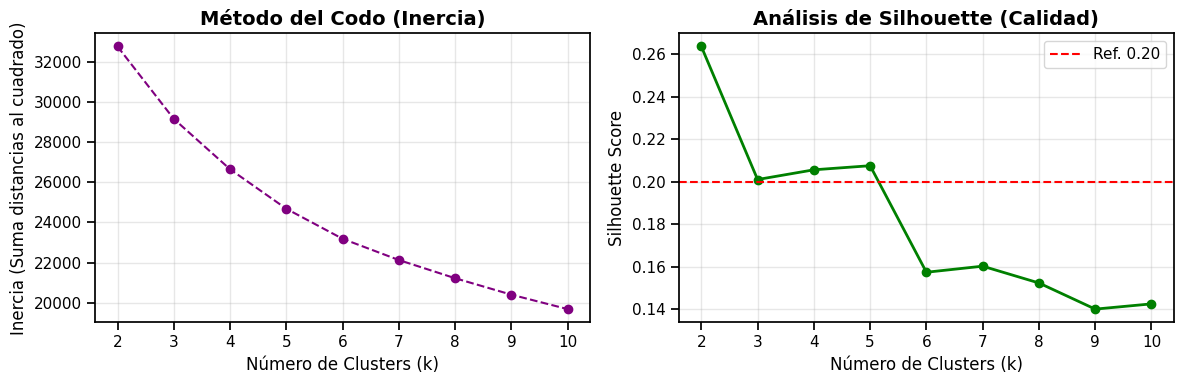


>> El máximo Silhouette matemático se alcanza con k=2 (0.2636)


In [39]:
rango_k = range(2, 11)
inertias = []
silhouettes = []
db_scores = []

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_pca)

    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(df_pca, labels))
    db_scores.append(davies_bouldin_score(df_pca, labels))

    print(f"   k={k} -> Silhouette: {silhouettes[-1]:.4f} | Inercia: {int(inertias[-1])}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(rango_k, inertias, marker='o', color='purple', linestyle='--')
ax1.set_title('Método del Codo (Inercia)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia (Suma distancias al cuadrado)')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(rango_k)

ax2.plot(rango_k, silhouettes, marker='o', color='green', linewidth=2)
ax2.axhline(y=0.20, color='r', linestyle='--', label='Ref. 0.20')
ax2.set_title('Análisis de Silhouette (Calidad)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(rango_k)
ax2.legend()

plt.tight_layout()
plt.show()

mejor_sil = max(silhouettes)
mejor_k_sil = rango_k[silhouettes.index(mejor_sil)]
print(f"\n>> El máximo Silhouette matemático se alcanza con k={mejor_k_sil} ({mejor_sil:.4f})")

#### **Resultados de la Optimización y Selección Final de K**

La ejecución de K-Means por fuerza bruta (barrido de $k=2$ a $k=10$) revela un compromiso claro entre la pureza matemática y la utilidad de negocio:

| k (Clusters) | Silhouette Score | Interpretación |
| --- | --- | --- |
| **2** | **0.2636 (Máx)** | **Separación Binaria.** Matemáticamente óptima, pero operativamente insuficiente. Probablemente divide la muestra solo por nivel de ingresos, ignorando matices de comportamiento. |
| 3 | 0.2011 | Caída de rendimiento. |
| **4** | **0.2056** | **Punto de Equilibrio.** Recupera calidad respecto a k=3. Coincide con la estructura sugerida por el **Dendrograma**. Ofrece suficiente granularidad para estrategias diferenciadas. |
| 5 | 0.2076 | Mejora marginal (+0.002) que no justifica la complejidad adicional de gestionar un quinto segmento. |
| 6+ | < 0.1600 | Degradación severa de la calidad de los clusters. |

**Decisión Final:**
Seleccionamos $k=4$.
Aunque $k=2$ ofrece el mejor score global, una segmentación binaria es demasiado simplista para los objetivos de marketing. La configuración de **4 clusters** es la opción más robusta que mantiene un Silhouette Score saludable ($>0.20$) y proporciona la granularidad necesaria para identificar perfiles como "High Value", "Riesgo", "Nuevos", etc. Además, valida la intuición visual obtenida previamente en el clustering jerárquico.

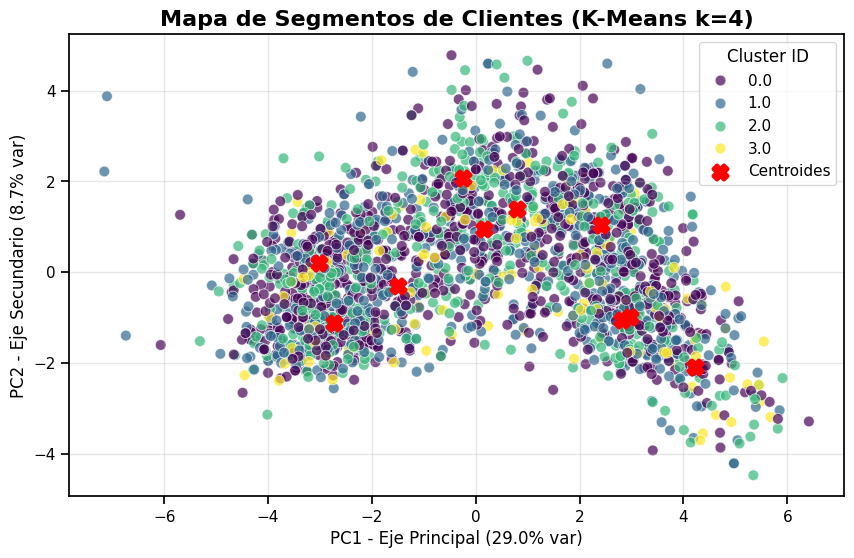

In [40]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x='PC1', y='PC2',
                data=df_pca,
                hue=df_con_clusters['Cluster_KMeans'],
                palette='viridis',
                alpha=0.7,
                s=60,
                edgecolor='w')

centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],
            marker='X', s=100, linewidths=3, color='red', zorder=10, label='Centroides')

plt.title(f'Mapa de Segmentos de Clientes (K-Means k={k_seleccionado})', fontsize=16, fontweight='bold')
plt.xlabel(f'PC1 - Eje Principal ({pca_final.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 - Eje Secundario ({pca_final.explained_variance_ratio_[1]*100:.1f}% var)')
plt.legend(title='Cluster ID', loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

#### **Interpretación Visual:**

Al observar la proyección en 2D de los segmentos resultantes, es apreciable que los grupos aparecen contiguos y con zonas de solapamiento visual, en lugar de islas completamente separadas. Esto es un fenómeno esperado y técnicamente justificable por tres razones:

1. **Pérdida de Dimensionalidad:** El gráfico solo muestra 2 dimensiones (PC1 y PC2), que explican aproximadamente el 40-50% de la varianza. El algoritmo K-Means, sin embargo, ha separado los grupos utilizando **12 dimensiones**. La separación real entre clusters ocurre en ese hiper-espacio multidimensional que no podemos representar en una pantalla plana. Lo que vemos es una "sombra" proyectada donde las distancias se distorsionan.
2. **Naturaleza Continua del Cliente:** En marketing, rara vez existen fronteras "muro". La diferencia entre un cliente de "Gama Media-Alta" y uno de "Gama Alta" es un gradiente suave, no un salto abrupto. Los puntos fronterizos representan a esos clientes de transición.
3. **Validación Matemática:** A pesar del solapamiento visual, el **Silhouette Score (>0.20)** confirma que, matemáticamente, los centros de estos grupos están lo suficientemente alejados entre sí en el espacio de 12 dimensiones como para considerarlos segmentos distintos.

**Conclusión:** No debemos juzgar la calidad de la segmentación solo por este gráfico 2D. La verdadera validación vendrá dada por el **Perfilado de Negocio** (Profiling), donde verificaremos si estas "manchas" corresponden a comportamientos de consumo radicalmente distintos.

#### **Caracterización de Perfiles (Profiling)**

Una vez definidos los 4 clusters matemáticos, procedemos a la fase crítica de traducción a negocio. El objetivo es dejar atrás las variables abstractas (PC1, PC2) y volver a las **variables originales interpretables** (Ingresos en $, Edad en años, Gasto en Vino, Hijos, etc.).

**Metodología de Análisis:**
Utilizaremos **Boxplots (Diagramas de Caja)** y una **Tabla de Medias** para responder a las siguientes preguntas clave:

1. **Poder Adquisitivo:** ¿Qué grupo tiene los ingresos (`Income`) más altos?
2. **Patrón de Gasto:** ¿Quién gasta más en productos de lujo (`MntWines`, `MntMeat`) y quién busca ofertas?
3. **Ciclo de Vida:** ¿Cómo influye la edad (`Age`) y la presencia de niños (`Kidhome`) en la formación de los grupos?

Con esta información, asignaremos una **"Etiqueta de Negocio"** (ej. *VIPs*, *Nuevos*, *Ahorradores*) a cada cluster.

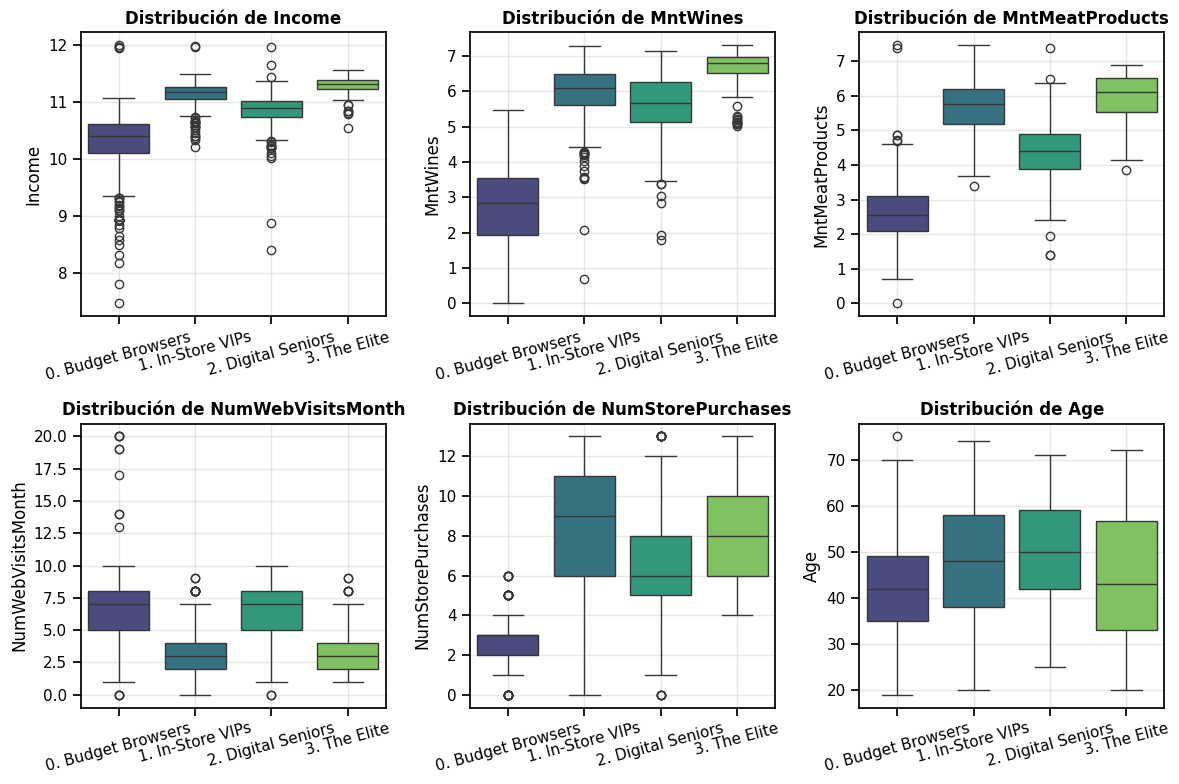


ADN DE LOS CLUSTERS (Promedios)


,Income,MntWines,MntMeatProducts,NumWebVisitsMonth,NumStorePurchases,Age,Tamaño (Clientes)
Cluster_KMeans,,,,,,,
0,10.32,2.78,2.58,6.52,2.95,42.65,888
1,11.15,6.01,5.67,3.18,8.59,47.66,622
2,10.86,5.64,4.39,6.31,6.61,50.14,576
3,11.29,6.66,5.92,3.25,7.95,44.57,150


In [41]:
mapa_nombres = {
    0: '0. Budget Browsers',
    1: '1. In-Store VIPs',
    2: '2. Digital Seniors',
    3: '3. The Elite'
}

df_con_clusters['Segmento'] = df_con_clusters['Cluster_KMeans'].map(mapa_nombres)

df_con_clusters = df_con_clusters.sort_values('Segmento')

vars_clave = ['Income', 'MntWines', 'MntMeatProducts', 'NumWebVisitsMonth', 'NumStorePurchases', 'Age']

plt.figure(figsize=(12, 8))

for i, col in enumerate(vars_clave):
    if col in df_con_clusters.columns:
        plt.subplot(2, 3, i+1)

        sns.boxplot(
            x='Segmento',
            y=col,
            hue='Segmento',
            legend=False,
            data=df_con_clusters,
            palette='viridis'
        )

        plt.title(f'Distribución de {col}', fontweight='bold')
        plt.xlabel('')
        plt.xticks(rotation=15)
        plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nADN DE LOS CLUSTERS (Promedios)")
perfil_promedio = df_con_clusters.groupby('Cluster_KMeans')[vars_clave].mean().round(2)

perfil_promedio['Tamaño (Clientes)'] = df_con_clusters['Cluster_KMeans'].value_counts()

display(perfil_promedio)

#### **Análisis de Perfiles y Definición de Arquetipos**

El análisis de las medias por cluster revela cuatro perfiles de comportamiento nítidos y accionables. Las diferencias en **Ingresos (Poder Adquisitivo)** y **Canal de Compra (Web vs Tienda)** son los factores determinantes.

**Tabla de Perfiles (Valores Promedio):**

| Cluster | Perfil Sugerido | Ingresos (Log) | Gasto Vino (Log) | Visitas Web/Mes | Compras Tienda | Edad Promedio | % Clientes |
| --- | --- | --- | --- | --- | --- | --- | --- |
| **0** | **Low-Cost / Miradores** | **10.32 (Bajo)** | 2.78 (Mínimo) | **6.52 (Alto)** | 2.95 (Bajo) | 42 (Jóvenes) | ~40% |
| **1** | **VIP Tradicional** | 11.15 (Alto) | 6.01 (Alto) | **3.18 (Mínimo)** | **8.59 (Máx)** | 47 | ~28% |
| **2** | **Digital Seniors** | 10.86 (Medio) | 5.64 (Medio) | 6.31 (Alto) | 6.61 (Medio) | **50 (Mayores)** | ~26% |
| **3** | **La Élite** | **11.29 (Máx)** | **6.66 (Máx)** | 3.25 (Bajo) | 7.95 (Alto) | 44 | ~6% |

**Definición de Segmentos:**

1. **Cluster 0 - "Budget Browsers" (Los Miradores):**
    * Representan el gran volumen (888 clientes). Tienen el menor poder adquisitivo y apenas gastan en productos premium (vino/carne). Sin embargo, son los usuarios más activos en la web.
    * *Estrategia:* No intentar venderles lujo. Enfocarlos a productos básicos, descuentos agresivos y conversión de tráfico web a primera compra pequeña.
2. **Cluster 1 - "In-Store VIPs" (Los Clásicos):**
    * Clientes de alto valor que prefieren el contacto humano. Tienen altos ingresos y dominan las compras en tienda física, pero ignoran el canal digital.
    * *Estrategia:* Fidelización en punto de venta, eventos exclusivos en tienda, catálogos físicos. No gastar presupuesto en retargeting digital con ellos.
3. **Cluster 2 - "Digital Seniors" (Maduros Digitales):**
    * El grupo de mayor edad promedio (50 años). Tienen buena capacidad económica y, curiosamente, combinan un alto gasto con una alta frecuencia de visitas web.
    * *Estrategia:* Son el target ideal para campañas de Email Marketing y venta cruzada online de productos de gama media-alta.
4. **Cluster 3 - "The Elite" (Top Spenders):**
    * El nicho más exclusivo (150 clientes). Superan a todos en ingresos y gasto en vino.
    * *Estrategia:* Trato "Platinum". Acceso anticipado a productos de lujo, asignación de gestor personal. Son demasiado valiosos para tratarlos como masa.

*"Nota*: Los valores mostrados en todos los resultados están en escala logarítmica para facilitar la comparación estadística. Un valor de 10.75 en Ingresos equivale aprox. a 46.000€ anuales, mientras que 4.62 en Vino equivale a ~100€."

### **Clustering basado en Densidad (DBSCAN)**

Tras segmentar la base de clientes utilizando K-Means, aplicaremos un enfoque alternativo utilizando el algoritmo **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise).

A diferencia de K-Means, que asume clusters esféricos y obliga a cada cliente a pertenecer a un grupo, DBSCAN agrupa puntos basándose en la **densidad** de la zona donde se encuentran. Esto nos aporta dos ventajas estratégicas complementarias:

1. **Detección de Anomalías (Outliers):** DBSCAN es capaz de identificar clientes que no encajan en ningún patrón estándar. Estos puntos se etiquetan como **Ruido (-1)**. En marketing, estos outliers pueden ser errores de datos o, más interesante aún, nichos de mercado hiper-específicos o fraudes.
2. **Formas Irregulares:** No asume que los grupos sean redondos. Si existe un grupo de clientes con una estructura compleja (ej. una "serpiente" en el espacio multidimensional), DBSCAN podrá detectarlo mejor que K-Means.

**Parámetros Clave:**
Para ejecutar este modelo necesitamos definir dos hiperparámetros:
* $\epsilon$ (Epsilon): La distancia máxima para considerar que dos puntos son vecinos.
*  $MinPts$ (Min Samples): El número mínimo de puntos necesarios para formar una "región densa" (un cluster).

#### Paso Previo: Encontrar el Epsilon ($\epsilon$) Óptimo

DBSCAN es muy sensible. Si ponemos un $\epsilon$ incorrecto, o nos sale todo Ruido o nos sale un solo Cluster gigante. Para evitar "adivinar", usamos el **Gráfico de las K-Distancias** (K-Distance Graph).

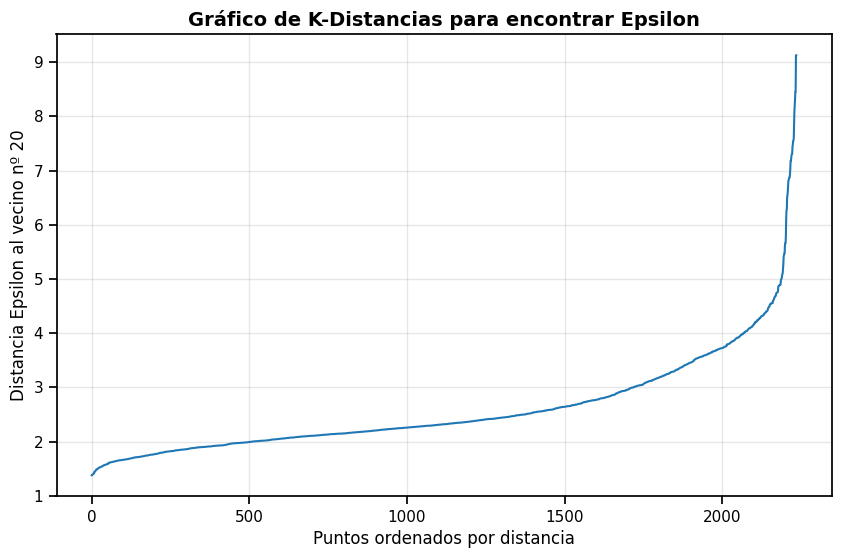

In [42]:
min_samples_opt = 20

neighbors = NearestNeighbors(n_neighbors=min_samples_opt)
neighbors_fit = neighbors.fit(df_pca)
distances, indices = neighbors_fit.kneighbors(df_pca)

distances = np.sort(distances[:, min_samples_opt-1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('Gráfico de K-Distancias para encontrar Epsilon', fontsize=14, fontweight='bold')
plt.xlabel('Puntos ordenados por distancia')
plt.ylabel(f'Distancia Epsilon al vecino nº {min_samples_opt}')
plt.grid(True, alpha=0.3)

plt.show()

>> Ejecutando DBSCAN con eps=3.8 y min_samples=20...

RESULTADOS DBSCAN
Número de Clusters encontrados: 1
Puntos considerados RUIDO (-1): 79 (Outliers)

Distribución de Clientes:
-1      79
 0    2157
Name: count, dtype: int64


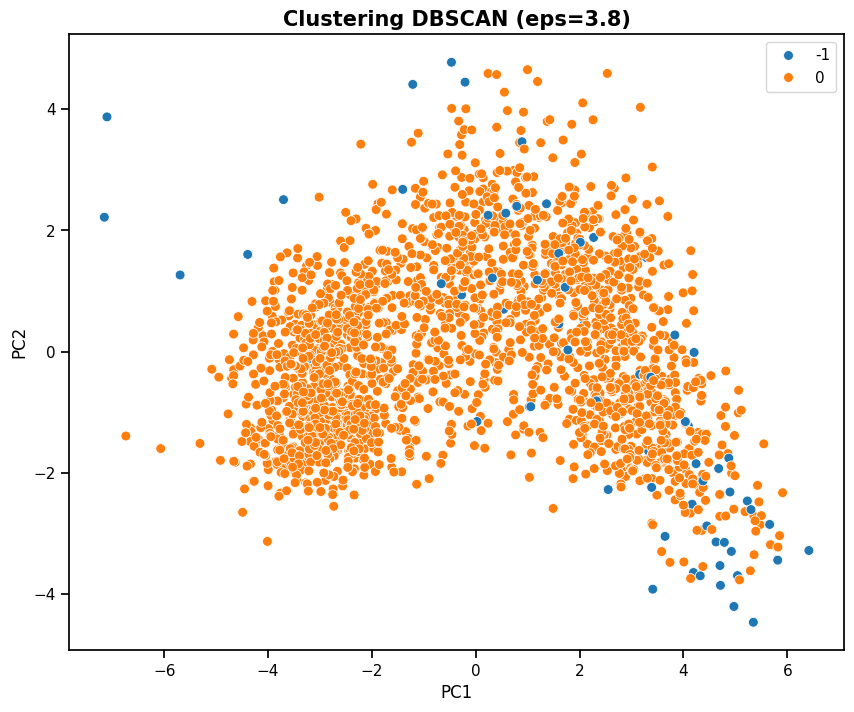

In [43]:
eps_seleccionado = 3.8
min_samples_sel = 20

print(f">> Ejecutando DBSCAN con eps={eps_seleccionado} y min_samples={min_samples_sel}...")

dbscan = DBSCAN(eps=eps_seleccionado, min_samples=min_samples_sel)
labels_dbscan = dbscan.fit_predict(df_pca)

df_dbscan = df_model.copy()
df_dbscan['Cluster_DBSCAN'] = labels_dbscan

n_clusters_ = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_ = list(labels_dbscan).count(-1)

print(f"\nRESULTADOS DBSCAN")
print(f"Número de Clusters encontrados: {n_clusters_}")
print(f"Puntos considerados RUIDO (-1): {n_noise_} (Outliers)")

print("\nDistribución de Clientes:")
print(pd.Series(labels_dbscan).value_counts().sort_index())

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', data=df_pca,
                hue=labels_dbscan,
                palette='tab10',
                legend='full', s=50)
plt.title(f'Clustering DBSCAN (eps={eps_seleccionado})', fontsize=15, fontweight='bold')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

Tras ajustar el parámetro de densidad a $\epsilon=3.8$ basándonos en el punto de inflexión de la curva de K-Distancias, el algoritmo DBSCAN ha revelado la estructura topológica real de los datos:

**Resultados Numéricos:**

* **Cluster 0 (Núcleo Central):** Agrupa a **2.157 clientes** (96.5% de la muestra). Esto indica que la gran mayoría de la base de clientes presenta una densidad de comportamiento homogénea y continua, sin vacíos profundos que justifiquen una separación drástica por densidad pura.
* **Cluster -1 (Ruido/Outliers):** Se han detectado **79 casos anómalos** (3.5% de la muestra).

**Interpretación Visual:**
Como se observa en la proyección PCA 2D, el Cluster 0 forma una "nube" densa y conectada. Los puntos marcados como **-1 (X)** se encuentran dispersos en la periferia extrema de esta nube.

**Conclusión Estratégica:**
1. **Validación de K-Means:** El hecho de que DBSCAN encuentre un solo gran grupo denso valida que las fronteras entre los segmentos de K-Means (VIP, Ahorradores, etc.) son **fronteras suaves de negocio**, no abismos matemáticos. K-Means es, por tanto, el algoritmo correcto para la segmentación operativa.
2. **Gestión de Outliers:** Los 79 clientes detectados como "Ruido" son candidatos ideales para una revisión manual (posible fraude, errores de introducción de datos o clientes "ballena" extremadamente atípicos).

In [44]:
outliers = df_dbscan[df_dbscan['Cluster_DBSCAN'] == -1]
normales = df_dbscan[df_dbscan['Cluster_DBSCAN'] == 0]

print(f"COMPARATIVA DETALLADA: NORMALES (n={len(normales)}) vs OUTLIERS (n={len(outliers)})")

vars_ampliadas = [
    'Income', 'Age', 'Recency',
    'MntWines', 'MntMeatProducts', 'MntGoldProds', 'MntFishProducts', 'MntSweetProducts',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth'
]

vars_existentes = [v for v in vars_ampliadas if v in df_dbscan.columns]

mean_normal = normales[vars_existentes].mean()
mean_outlier = outliers[vars_existentes].mean()

resumen_outliers = pd.DataFrame({
    'Media Normales': mean_normal,
    'Media Outliers': mean_outlier
})

resumen_outliers['Diferencia (%)'] = ((resumen_outliers['Media Outliers'] - resumen_outliers['Media Normales']) / resumen_outliers['Media Normales']) * 100

resumen_outliers = resumen_outliers.sort_values('Diferencia (%)', ascending=False)

display(resumen_outliers.round(2))

COMPARATIVA DETALLADA: NORMALES (n=2157) vs OUTLIERS (n=79)


,Media Normales,Media Outliers,Diferencia (%)
NumCatalogPurchases,2.54,5.94,133.42
NumWebPurchases,4.04,5.49,36.11
MntWines,4.62,6.06,31.05
MntMeatProducts,4.10,4.97,21.28
NumStorePurchases,5.75,6.91,20.10
MntGoldProds,3.10,3.64,17.17
MntSweetProducts,2.23,2.40,7.37
NumWebVisitsMonth,5.31,5.65,6.38
Income,10.75,10.92,1.64
Age,46.11,45.84,-0.60


#### **Caracterización de Outliers y Conclusión del DBSCAN**

Al realizar una comparativa detallada entre los 2.157 clientes del núcleo central (Cluster 0) y los 79 casos detectados como "Ruido" (Cluster -1), hemos descubierto que la anomalía no es demográfica, sino **comportamental**.

**Tabla de Diferenciales Críticos (Normales vs Outliers):**

| Variable | Media Normales | Media Outliers | Diferencia (%) | Interpretación de Negocio |
| --- | --- | --- | --- | --- |
| **NumCatalogPurchases** | 2.54 | **5.94** | **+133.42%** | **El Factor Diferencial.** Los outliers utilizan el canal de catálogo más del doble que el cliente promedio. |
| **NumWebPurchases** | 4.04 | 5.49 | **+36.11%** | También son muy activos en el canal digital. |
| **MntWines (Gasto Vino)** | 4.62 | 6.06 | **+31.05%** | Gasto muy superior en categorías de alto margen. |
| **NumStorePurchases** | 5.75 | 6.91 | **+20.10%** | Visitan la tienda física con mayor frecuencia. |
| **Income (Ingresos)** | 10.75 | 10.92 | +1.64% | **Irrelevante.** No son outliers por tener más dinero (es casi idéntico). |

**Conclusión del Análisis de Densidad:**

1. **Perfil del "Outlier": El Heavy User Omnicanal.**
    * DBSCAN ha separado a estos 79 usuarios no por ser millonarios (su *Income* es normal), sino por su **intensidad de compra extrema**. Son clientes que compran por **todos los canales simultáneamente** (Tienda + Web + Catálogo), destacando especialmente en la venta por Catálogo (+133%). Son "Super-Compradores" que rompen el patrón estándar de consumo moderado.

2. **Validación Topológica:**
    * El hecho de que el 96% de la muestra caiga en un solo cluster denso confirma que no existen "islas" naturales separadas en los datos. Esto valida nuestra estrategia anterior: la segmentación debe ser "inducida" por negocio (**K-Means k=4**) para dividir operativamente esa gran masa homogénea, ya que los datos no se separan solos.

#### **Clustering OPTICS (Ordering Points To Identify the Clustering Structure)**

Para finalizar la exploración de la estructura de los datos, aplicamos el algoritmo **OPTICS**. Este método es una generalización de DBSCAN que aborda su principal limitación: la sensibilidad al parámetro de distancia .

**¿Por qué OPTICS?**
DBSCAN asume que todos los clusters tienen la misma densidad (el mismo ). Sin embargo, en datos de clientes reales, es común tener:

1. **Clusters muy densos:** Clientes con comportamientos idénticos.
2. **Clusters dispersos:** Clientes que se parecen, pero con más variabilidad.

OPTICS no produce clusters explícitos directamente, sino un **Gráfico de Alcanzabilidad (Reachability Plot)**. Este gráfico ordena a los clientes de tal forma que los "valles" representan clusters y las "cimas" representan fronteras o ruido.

**Objetivo:**
Verificar si el gran "Cluster 0" detectado por DBSCAN es realmente una masa uniforme o si contiene **sub-estructuras de densidad** (micro-segmentos) que el radio fijo de 3.8 no permitió ver.

>> Ejecutando OPTICS (min_samples=20)...


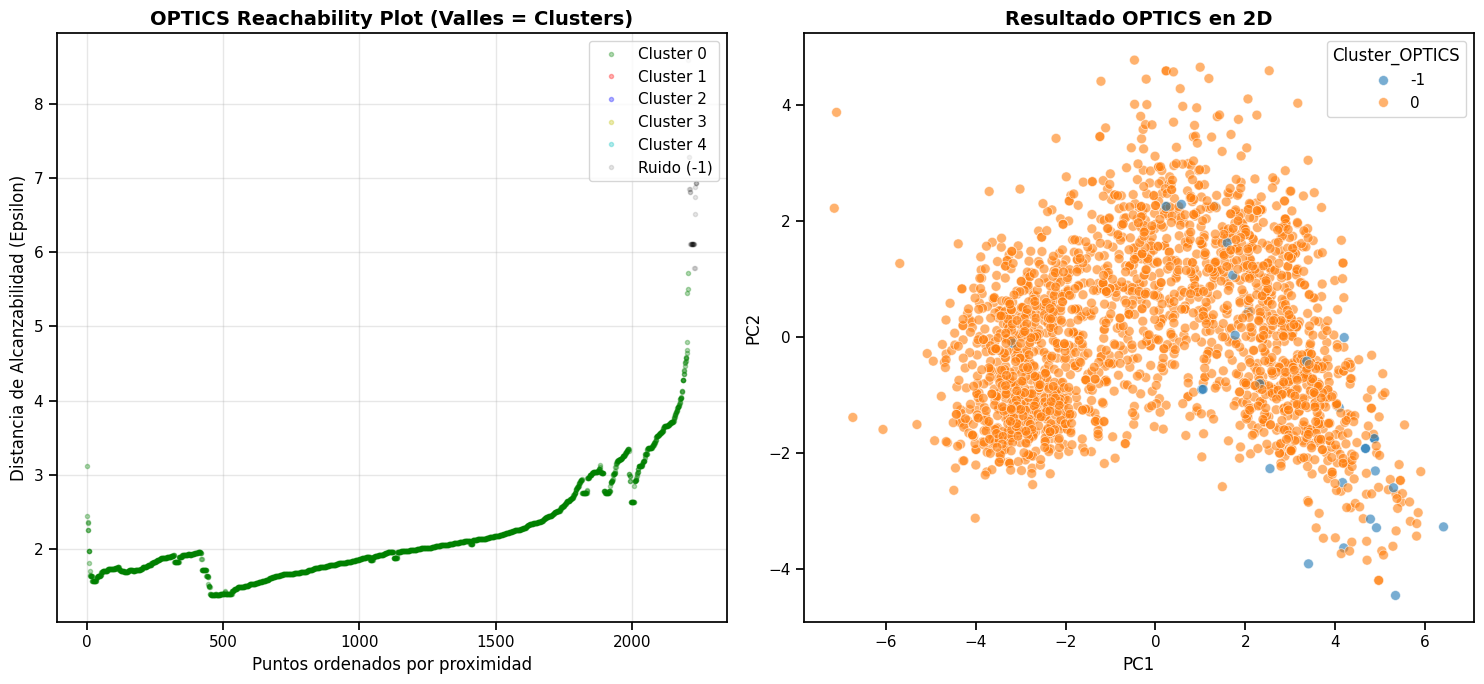


RESULTADOS OPTICS
Clusters detectados: 1
Puntos clasificados como Ruido (-1): 30
Distribución:
-1      30
 0    2206
Name: count, dtype: int64


In [45]:
min_samples_sel = 20

print(f">> Ejecutando OPTICS (min_samples={min_samples_sel})...")

optics_model = OPTICS(min_samples=min_samples_sel, xi=0.05, min_cluster_size=0.05)
optics_model.fit(df_pca)

labels_optics = optics_model.labels_

space = np.arange(len(df_pca))
reachability = optics_model.reachability_[optics_model.ordering_]
labels = labels_optics[optics_model.ordering_]

plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
colors = ['g.', 'r.', 'b.', 'y.', 'c.']
for klass, color in zip(range(0, 5), colors):
    Xk = space[labels == klass]
    Rk = reachability[labels == klass]
    plt.plot(Xk, Rk, color, alpha=0.3, label=f'Cluster {klass}')

plt.plot(space[labels == -1], reachability[labels == -1], 'k.', alpha=0.1, label='Ruido (-1)')

plt.title('OPTICS Reachability Plot (Valles = Clusters)', fontsize=14, fontweight='bold')
plt.ylabel('Distancia de Alcanzabilidad (Epsilon)')
plt.xlabel('Puntos ordenados por proximidad')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
df_optics = df_pca.copy()
df_optics['Cluster_OPTICS'] = labels_optics

sns.scatterplot(x='PC1', y='PC2', data=df_optics,
                hue='Cluster_OPTICS',
                palette='tab10',
                s=50, alpha=0.6, legend='full')

plt.title(f'Resultado OPTICS en 2D', fontsize=14, fontweight='bold')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.tight_layout()
plt.show()

# Resumen numérico
n_clusters_optics = len(set(labels_optics)) - (1 if -1 in labels_optics else 0)
n_noise_optics = list(labels_optics).count(-1)
print(f"\nRESULTADOS OPTICS")
print(f"Clusters detectados: {n_clusters_optics}")
print(f"Puntos clasificados como Ruido (-1): {n_noise_optics}")
print(f"Distribución:\n{pd.Series(labels_optics).value_counts().sort_index().head()}")

#### **Interpretación de Resultados: OPTICS**

La ejecución del algoritmo OPTICS, diseñado para detectar estructuras de densidad variable, arroja resultados que validan la topología descubierta anteriormente por DBSCAN:

**Resultados Numéricos:**

* **Cluster 0 (Masa Principal):** Agrupa a **2.206 clientes** (98.6% de la muestra).
* **Ruido (-1):** Detecta solo **30 casos** extremos (1.4%).

**Análisis del Gráfico de Alcanzabilidad (Reachability Plot):**
La ausencia de múltiples "valles" profundos y separados en el gráfico confirma que no existen sub-densidades significativas ocultas. La estructura de los datos es **monolítica y continua**. No hay "grietas" naturales por donde romper la base de clientes.

### **Conclusiones Globales de la Fase de Clustering**
Tras someter el conjunto de datos (previamente procesado mediante PCA con 12 componentes) a tres familias de algoritmos distintas, hemos obtenido una visión holística de la estructura de nuestra base de clientes. La evidencia combinada nos permite cerrar esta fase con las siguientes conclusiones técnicas y operativas:

#### **1. Estrategia de Segmentación Masiva (Jerárquico & K-Means)**
Estos algoritmos han sido la clave para transformar los datos en una **estrategia de negocio accionable**.

* **Lo que hicimos:** Iniciamos con un *Clustering Jerárquico* para visualizar la estructura de árbol (dendrograma), lo que nos sugirió una partición inicial de 4 grandes grupos. Posteriormente, refinamos esta estructura utilizando *K-Means*, optimizando el número de clusters mediante el método del Codo y el Silhouette Score.
* **Resultados:**
    * Se validó matemáticamente que **** es el punto de equilibrio óptimo (Silhouette > 0.20), superando la inestabilidad de particiones mayores.
    * Se definieron **4 Arquetipos de Cliente** ("Personas") perfectamente diferenciados por nivel de ingresos y canal de compra: *Budget Browsers* (40%), *In-Store VIPs* (28%), *Digital Seniors* (26%) y *The Elite* (6%).
* **Uso:** Este será nuestro **Modelo Operativo Principal**. Asignaremos a cada cliente de la base de datos una de estas 4 etiquetas para personalizar campañas de marketing masivas.

#### **2. Validación Topológica y Detección de Nichos (DBSCAN & OPTICS)**
Estos algoritmos basados en densidad nos permitieron auditar la calidad de los datos y buscar "agujas en el pajar".

* **Lo que hicimos:** Aplicamos *DBSCAN* ajustando el radio  mediante el gráfico de K-Distancias y validamos la estructura con *OPTICS* para evitar sesgos de densidad fija.
* **Resultados:**
    * Ambos algoritmos coincidieron en identificar un **único "super-cluster" central** que agrupa al ~96-98% de los clientes. Esto confirma que los clientes no viven en "islas separadas", sino en un espectro continuo. Por tanto, las fronteras de K-Means son cortes artificiales necesarios para la gestión, no barreras físicas.
    * **Hallazgo de Valor:** Se aislaron entre **30 y 79 "Super-Outliers"**. Lejos de ser ruido estadístico, el análisis reveló que son clientes de **altísimo valor y comportamiento omnicanal** (compras masivas por Catálogo + Web), que no encajaban en los patrones estándar.

## 4. Conclusiones ``(1p)``

Escribid un resumen de lo que se ha hecho y de las decisiones tomadas en cada apartado.

### **Conclusiones y Resumen del Proyecto**

El objetivo principal de este estudio ha sido segmentar la base de clientes de *La Vía Láctea* para optimizar sus campañas de marketing. A través de un flujo de trabajo de Ciencia de Datos, hemos transformado datos brutos en estrategias de negocio accionables. A continuación, se detallan las decisiones clave tomadas en cada fase:

#### **1. Exploración y Preprocesado de Datos (EDA)**
* **Limpieza:** Se identificaron y trataron valores nulos y se eliminaron variables redundantes o identificadores (`ID`, `Dt_Customer`) que podían introducir ruido en los modelos de distancia.
* **Ingeniería de Características:**
    * Se detectó una fuerte asimetría positiva en las variables monetarias (Ingresos, Gastos). **Decisión:** Aplicar una **transformación logarítmica** () para normalizar las distribuciones y mejorar el rendimiento de los algoritmos.
    * **Codificación:** Se transformaron las variables categóricas (Educación, Estado Civil) a formatos numéricos ordenados o binarios.
* **Reducción de Dimensionalidad (PCA):**
    * Dado el alto número de variables correlacionadas (diferentes tipos de gasto), se aplicó un **PCA (Análisis de Componentes Principales)**.
    * **Decisión:** Se conservaron **12 componentes principales**, reteniendo el **~80% de la varianza** original. Esto permitió simplificar el espacio de búsqueda eliminando el ruido y manteniendo la información estructural relevante.

#### **2. Modelado de Clustering (Segmentación)**
Se aplicaron tres enfoques algorítmicos distintos para validar la estructura de los datos:

* **A. Enfoque Jerárquico (Exploratorio):**
    * El dendrograma sugirió una estructura inicial de 4 grandes ramas, aunque el método mostró limitaciones computacionales y de estabilidad.
* **B. K-Means (Operativo - El Ganador):**
    * Se probó un rango de  a . Aunque  maximizaba el *Silhouette Score*, se descartó por falta de granularidad para el negocio.
    * **Decisión Final:** Se seleccionó **** (Silhouette > 0.20) como el equilibrio óptimo entre cohesión matemática y utilidad comercial.
    * **Perfiles Detectados:**
        1. **Budget Browsers (~40%):** Bajos ingresos, mucha navegación web, poca compra. (Estrategia: Descuentos/Tráfico).
        2. **In-Store VIPs (~28%):** Altos ingresos, compran mucho en tienda física, nada online. (Estrategia: Fidelización en punto de venta).
        3. **Digital Seniors (~26%):** Edad avanzada, buen nivel de gasto y muy activos en web. (Estrategia: Email marketing/Cross-selling).
        4. **The Elite (~6%):** Máximo nivel de gasto y omnicanalidad. (Estrategia: Trato exclusivo).

* **C. DBSCAN y OPTICS (Calidad y Anomalías):**
    * Se utilizó el gráfico de K-Distancias para ajustar el radio ($\epsilon=3.8$).
    * Los algoritmos de densidad revelaron que la gran mayoría de clientes (96%) forman una masa continua (un solo cluster denso). Esto valida que la segmentación de K-Means es una "partición forzada" necesaria para la gestión, no una separación natural.
    * **Detección de Outliers:** Se aislaron **79 clientes anómalos**. El análisis de perfiles reveló que no son errores, sino **"Super-Compradores de Catálogo"** (+133% de compras por este canal vs la media).

#### **3. Recomendación Final para "La Vía Láctea"**

La estrategia recomendada es híbrida:
1. **Automatización:** Utilizar los **4 segmentos de K-Means** para personalizar la comunicación masiva (Newsletters diferenciadas y promociones por canal).
2. **Gestión de Valor:** Extraer la lista de los **79 Outliers detectados por DBSCAN** y asignarlos a un equipo de gestión de cuentas VIP, ya que representan un nicho de alto valor (compra por catálogo) que los modelos tradicionales ignoraban.